# Modelagem computacional de um acidente envolvendo vazamento de estireno em Manaus

Em 15 de julho de 2026, ocorreu uma emergência química em um dos tanques de armazenamento de monômero de estireno da empresa Innova, localizada no Distrito Industrial de Manaus (AM). Segundo informações divulgadas pela empresa, uma elevação anormal da temperatura do líquido provocou a liberação de vapores por meio dos dispositivos de segurança do equipamento. Imagens térmicas registradas após o incidente indicaram que o casco do tanque atingiu temperatura média de aproximadamente **72 °C**.

O episódio levou 149 pessoas a procurarem atendimento médico, com relatos de sintomas associados à exposição aos vapores da substância.

## 1. O que é o estireno?

O estireno ($\mathrm{C_8H_8}$) é um composto orgânico utilizado como matéria-prima na fabricação de diversos materiais, incluindo poliestireno (isopor), plásticos ABS, borrachas sintéticas e resinas empregadas em produtos industriais.

À temperatura ambiente, apresenta-se como um líquido incolor e volátil, cujos vapores possuem odor característico. A substância é inflamável e sua inalação pode causar efeitos adversos à saúde, especialmente em concentrações elevadas.

## 2. Efeitos da exposição

Entre os sintomas associados à exposição aos vapores de estireno estão irritação dos olhos e das vias respiratórias, dor de cabeça, tontura, náuseas e dificuldade respiratória. Esses efeitos foram relatados durante o atendimento às pessoas afetadas pelo incidente em Manaus.

## 3. Fenômenos investigados no modelo

A modelagem computacional permite investigar diferentes fenômenos físicos relacionados ao acidente, organizados nas seguintes etapas do notebook:

1. Bibliotecas: importação das ferramentas computacionais utilizadas na implementação dos modelos.
2. Dados do tanque: caracterização geométrica e construtiva do reservatório.
3. Propriedades do estireno: levantamento das propriedades físico-químicas necessárias à modelagem.
4. Dados ambientais: obtenção e organização das informações meteorológicas utilizadas na simulação.
5. Transferência de calor: investigação dos mecanismos de aquecimento do sistema, incluindo radiação solar, convecção, condução pela parede e balanço de energia.
6. Evaporação: estimativa da quantidade de estireno que pode passar para a fase de vapor.
7. Pressão interna: análise da pressão desenvolvida no interior do tanque a partir de diferentes modelos físicos.
8. Energia liberada pela polimerização: investigação da possível contribuição da reação exotérmica para a elevação da temperatura.
9. Integridade estrutural: avaliação dos efeitos da pressão interna sobre a estrutura do reservatório.
10. Dispersão atmosférica: modelagem da propagação do estireno na atmosfera após sua liberação.
11. Síntese e considerações finais

## 4. Como utilizar a modelagem computacional

A modelagem foi desenvolvida em Python e disponibilizada em um notebook interativo no Google Colab. Para utilizá-la, o estudante deve obter os dados meteorológicos no NASA POWER, conforme as orientações do **Apêndice A**, e carregar o arquivo CSV no notebook.

Em seguida, basta executar as células sequencialmente, clicando no botão Play (▶), localizado no canto superior esquerdo de cada célula executável. É altamente recomendado a leitura do texto contindo antes de cada célula executável.Os parâmetros editáveis estão indicados com marcações de início e fim de dados editáveis, sempre no início das células executáveis. O usuário poderá modificar os parâmetros indicados, se necessário, e analisar os gráficos e resultados gerados.

Os resultados são gerados logo abaixo das células executáveis.

## 5. Questões investigativas

A investigação do acidente com estireno em Manaus será conduzida por meio de questões que orientam a construção progressiva de modelos físicos e computacionais. No início de cada etapa é apresentado uma questão investigativa , um modelo físico e os resultados correspondentes, permitindo explorar os fenômenos envolvidos no acidente e compreender as relações entre eles.

Ao longo do notebook, os estudantes poderão modificar parâmetros, testar hipóteses, comparar cenários e analisar as limitações dos modelos, utilizando a simulação computacional como ferramenta para produzir evidências e construir explicações para o fenômeno investigado.

<div align="center">

<h2><u>Questão central da investigação</u></h2>


<h2>Os mecanismos físicos considerados no modelo são suficientes para explicar a evolução térmica observada durante o acidente com estireno em Manaus?</h2>

</div>


## 1 – Bibliotecas

Nesta etapa são importadas as bibliotecas necessárias à execução dos modelos computacionais. Elas fornecem recursos para operações matemáticas, cálculos numéricos, organização dos dados e geração de gráficos.

O usuário não precisa modificar esta seção. Os parâmetros utilizados nas simulações são definidos em uma etapa específica, apresentada a seguir.

**Orientação de execução:** Para iniciar a célula abaixo, execute clicando no botão Play (▶), localizado no canto superior esquerdo.

In [33]:
# ==========================================================
# 1 - Bibliotecas
# ==========================================================
from dataclasses import dataclass, field
import math
import numpy as np
import textwrap

## 2 – Dados do tanque

<div align="center">

<h3>Como representar geometricamente o tanque de armazenamento envolvido no acidente?<h3>
</div>

Para responder a essa questão, serão investigadas as dimensões, a capacidade e as características construtivas do tanque, de modo a estabelecer uma representação geométrica adequada à modelagem térmica.

<div align="center">

<h3>Como estimar a massa do casco metálico?</h3>

</div>

A estimativa da massa do casco metálico é importante para determinar a capacidade térmica da estrutura e avaliar sua participação nos processos de transferência de calor. Para isso, são consideradas as dimensões do tanque, as espessuras das chapas de aço e a densidade do material. <br><br>

Os dados geométricos e construtivos do tanque foram obtidos a partir de duas fontes complementares. Inicialmente, as dimensões do tanque envolvido no acidente foram estimadas por meio de medições realizadas com as ferramentas de régua do Google Maps e do Google Earth, resultando em um diâmetro aproximado de 28 m e uma altura de 18 m. Em seguida, foi realizada uma pesquisa bibliográfica com o objetivo de identificar um tanque com características semelhantes.

O tanque descrito por **Agho et al. (2017)** apresentou boa concordância com as dimensões estimadas a partir das imagens de satélite. O projeto considera um tanque com **27,4 m de diâmetro**, **17,5 m de altura** e capacidade nominal de **10.000 m³**, construído conforme a norma **API 650 (12ª edição)**, utilizando aço **ASTM A36**. A estrutura possui teto cônico (*cone roof*), sete cursos cilíndricos (*shell courses*) de 2,5 m de altura e uma sobreespessura para corrosão (*corrosion allowance*) de 3 mm.

Dessa forma, os dados construtivos adotados neste simulador foram baseados no trabalho de Agho et al. (2017), devido à compatibilidade entre as dimensões do projeto e as estimativas realizadas para o tanque envolvido no acidente, além da disponibilidade de informações necessárias à modelagem geométrica e térmica do sistema.

**Referência utilizada para a geometria:**

*Design, Construction and Testing of a Petroleum Product Storage Tank (10 Million Litre Capacity).*

DOI: https://doi.org/10.24018/ejers.2017.2.3.308

**Observações sobre as hipóteses adotadas:**

* Apenas a geometria e as características construtivas do tanque descrito no artigo foram utilizadas neste trabalho.
* As propriedades do fluido foram substituídas pelas propriedades físico-químicas do estireno (*styrene*), não sendo utilizada a densidade do produto considerado no artigo original.
* Para simplificar a modelagem térmica, o teto cônico foi desconsiderado, representando-se o tanque como um cilindro vertical de mesma altura e diâmetro.

# Parâmetros editáveis:

 Os valores de referência apresentados na próxima célula de código podem ser modificados pelo usuário para investigar diferentes configurações geométricas, características construtivas e condições operacionais do tanque. Os parâmetros editáveis estão identificados e agrupados no início do código, enquanto as propriedades geométricas e os cálculos são atualizados automaticamente a partir dos valores fornecidos. Recomenda-se executar novamente as células subsequentes após qualquer alteração, a fim de garantir a atualização dos resultados da simulação.


In [34]:
# ==========================================================
# 2 - DADOS DO TANQUE
# ==========================================================

@dataclass
class Tanque:

    # ======================================================
    # >>> DADOS EDITÁVEIS PELO USUÁRIO <<<
    # ======================================================

    # ------------------------------------------------------
    # GEOMETRIA
    # ------------------------------------------------------

    diametro: float = 27.4       # Diâmetro do tanque (m)
    altura: float = 17.5         # Altura do tanque (m)

    # ------------------------------------------------------
    # DADOS CONSTRUTIVOS
    # ------------------------------------------------------

    norma: str = "API 650 (12th Edition)"

    referencia: str = (
        "Agho et al. (2017). Design, Construction and Testing "
        "of a Petroleum Product Storage Tank (10 Million Litre "
        "Capacity). European Journal of Engineering and "
        "Technology Research, 2(3). "
        "https://doi.org/10.24018/ejers.2017.2.3.308"
    )

    material: str = "ASTM A36"

    capacidade_nominal: float = 10000.0  # m³

    tipo_teto: str = "Cone Roof"

    numero_shell_courses: int = 7

    altura_shell_course: float = 2.5  # m

    corrosion_allowance: float = 0.003  # m

    # Espessuras dos cursos, de baixo para cima (m)

    espessuras: list = field(default_factory=lambda: [
        0.014,  # Curso 1
        0.012,  # Curso 2
        0.010,  # Curso 3
        0.010,  # Curso 4
        0.008,  # Curso 5
        0.006,  # Curso 6
        0.006   # Curso 7
    ])

    # ------------------------------------------------------
    # CONDIÇÕES OPERACIONAIS
    # ------------------------------------------------------

    nivel_liquido: float = 0.90  # Fração do volume (0 a 1)

    temperatura_liquido: float = 30.0   # °C

    temperatura_parede: float = 30.0    # °C

    temperatura_ambiente: float = 30.0  # °C

    pressao_interna: float = 101325.0   # Pa

    # ------------------------------------------------------
    # PROPRIEDADES DO MATERIAL DO TANQUE
    # ------------------------------------------------------

    densidade_aco: float = 7850.0          # kg/m³

    calor_especifico_aco: float = 490.0    # J/(kg.K)

    condutividade_aco: float = 50.0        # W/(m.K)

    # ======================================================
    # >>> FIM DOS DADOS EDITÁVEIS <<<
    # ======================================================


    # ======================================================
    # PROPRIEDADES GEOMÉTRICAS
    # Não é necessário modificar esta parte.
    # ======================================================

    @property
    def raio(self):
        return self.diametro / 2

    @property
    def area_base(self):
        return math.pi * self.raio**2

    @property
    def area_lateral(self):
        return math.pi * self.diametro * self.altura

    @property
    def area_total(self):
        return self.area_lateral + 2 * self.area_base

    @property
    def volume_total(self):
        return self.area_base * self.altura

    @property
    def altura_liquido(self):
        return self.altura * self.nivel_liquido

    @property
    def volume_liquido(self):
        return self.volume_total * self.nivel_liquido

    @property
    def volume_vapor(self):
        return self.volume_total - self.volume_liquido


    # ======================================================
    # MASSA DO CASCO
    # ======================================================

    def massa_shell(self):

        area_curso = (
            math.pi *
            self.diametro *
            self.altura_shell_course
        )

        massa = 0

        for esp in self.espessuras:

            volume = area_curso * esp

            massa += volume * self.densidade_aco

        return massa


    # ======================================================
    # RESUMO DOS DADOS E RESULTADOS
    # ======================================================

    def resumo(self):

        print("=" * 60)
        print("DADOS DO TANQUE")
        print("=" * 60)

        print(f"Norma.................... {self.norma}")
        print(f"Material................. {self.material}")
        print(f"Teto..................... {self.tipo_teto}")
        print(f"Capacidade nominal....... {self.capacidade_nominal:.0f} m³")

        print()

        print(f"Diâmetro................. {self.diametro:.2f} m")
        print(f"Altura................... {self.altura:.2f} m")
        print(f"Raio..................... {self.raio:.2f} m")

        print()

        print(f"Nº de cursos............. {self.numero_shell_courses}")
        print(f"Altura por curso......... {self.altura_shell_course:.2f} m")
        print(f"Corrosion allowance...... {self.corrosion_allowance*1000:.0f} mm")

        print()

        print("Espessuras dos cursos (mm)")

        for i, esp in enumerate(self.espessuras):
            print(f"   Curso {i+1}: {esp*1000:.0f}")

        print()

        print(f"Área lateral............. {self.area_lateral:.2f} m²")
        print(f"Área total............... {self.area_total:.2f} m²")

        print()

        print(f"Volume total............. {self.volume_total:.2f} m³")
        print(f"Volume líquido........... {self.volume_liquido:.2f} m³")
        print(f"Volume vapor............. {self.volume_vapor:.2f} m³")

        print()

        print(f"Nível do líquido......... {100*self.nivel_liquido:.1f} %")

        print()

        print(f"Massa do casco........... {self.massa_shell():.0f} kg")

        print(f"Densidade do aço......... {self.densidade_aco:.0f} kg/m³")

        print(
            f"Calor específico do aço.. "
            f"{self.calor_especifico_aco:.1f} J/(kg.K)"
        )

        print(
            f"Condutividade do aço..... "
            f"{self.condutividade_aco:.1f} W/(m.K)"
        )

        print()
        print("REFERÊNCIA")
        print()
        print(self.referencia)

        print("=" * 60)


# ==========================================================
# CRIAÇÃO DO OBJETO E EXIBIÇÃO DOS RESULTADOS
# ==========================================================

tanque = Tanque()

tanque.resumo()

DADOS DO TANQUE
Norma.................... API 650 (12th Edition)
Material................. ASTM A36
Teto..................... Cone Roof
Capacidade nominal....... 10000 m³

Diâmetro................. 27.40 m
Altura................... 17.50 m
Raio..................... 13.70 m

Nº de cursos............. 7
Altura por curso......... 2.50 m
Corrosion allowance...... 3 mm

Espessuras dos cursos (mm)
   Curso 1: 14
   Curso 2: 12
   Curso 3: 10
   Curso 4: 10
   Curso 5: 8
   Curso 6: 6
   Curso 7: 6

Área lateral............. 1506.39 m²
Área total............... 2685.68 m²

Volume total............. 10318.80 m³
Volume líquido........... 9286.92 m³
Volume vapor............. 1031.88 m³

Nível do líquido......... 90.0 %

Massa do casco........... 111495 kg
Densidade do aço......... 7850 kg/m³
Calor específico do aço.. 490.0 J/(kg.K)
Condutividade do aço..... 50.0 W/(m.K)

REFERÊNCIA

Agho et al. (2017). Design, Construction and Testing of a Petroleum Product Storage Tank (10 Million Litre Capacit

## 3 – Propriedades do estireno

<div align="center"> <h3>Quais propriedades do estireno são necessárias para descrever a evolução física do acidente?</h3> </div>

O estireno (C₈H₈) é um hidrocarboneto aromático amplamente utilizado na produção de polímeros, sendo classificado como um líquido inflamável e volátil. Suas propriedades físico-químicas influenciam diretamente os fenômenos de transferência de calor, evaporação, pressurização e dispersão atmosférica, tornando sua correta caracterização fundamental para a simulação do acidente.

As propriedades adotadas neste trabalho foram compiladas a partir de bases de dados e documentos técnicos reconhecidos internacionalmente, incluindo o NIST Chemistry WebBook, o ATSDR – Toxicological Profile for Styrene, o National Toxicology Program (NTP) e o AmSty – Styrene Monomer Safe Handling Guide. Foram selecionados parâmetros relevantes para a modelagem térmica e físico-química do sistema, como densidade, calor específico, condutividade térmica, viscosidade, calor de vaporização, pressão de vapor e limites de inflamabilidade.

**Parâmetros editáveis:** Os valores de referência das propriedades físico-químicas do estireno estão definidos no início da próxima célula de código e podem ser modificados pelo usuário para investigar diferentes condições e cenários. A estrutura do código permite que as alterações sejam incorporadas aos cálculos subsequentes, desde que as células correspondentes sejam executadas novamente.

**Orientação de execução:** Para executar a célula clique no botão Play (▶), localizado no canto superior esquerdo. Caso algum parâmetro seja alterado, execute novamente a célula e as células subsequentes para atualizar os resultados.


In [35]:

# ==========================================================
# >>> DADOS EDITÁVEIS PELO USUÁRIO <<<
# ==========================================================

# Identificação
NOME_ESTIRENO = "Estireno"
FORMULA_ESTIRENO = "C8H8"
CAS_ESTIRENO = "100-42-5"
MASSA_MOLAR_ESTIRENO = 104.15       # g/mol

# Propriedades físicas
DENSIDADE_ESTIRENO = 906.0          # kg/m³ (25 °C)
DENSIDADE_VAPOR = 3.6               # ar = 1
TEMPERATURA_FUSAO = -30.6           # °C
TEMPERATURA_EBULICAO = 145.2        # °C
TEMPERATURA_CRITICA = 363.8         # °C
PRESSAO_CRITICA = 3.83e6            # Pa

# Propriedades térmicas
CALOR_ESPECIFICO_ESTIRENO = 1730.0  # J/(kg.K)
CONDUTIVIDADE_ESTIRENO = 0.13       # W/(m.K)
VISCOSIDADE_ESTIRENO = 0.00072      # Pa.s
CALOR_VAPORIZACAO = 35200.0         # J/mol

# Propriedades do vapor
PRESSAO_VAPOR = 640.0               # Pa (25 °C)

# Propriedades de segurança
FLASH_POINT = 31.0                  # °C
AUTOIGNICAO = 490.0                 # °C
LIMITE_INFERIOR = 1.1               # %
LIMITE_SUPERIOR = 6.1               # %

# Referências bibliográficas
REFERENCIAS_ESTIRENO = (
    "NIST Chemistry WebBook",
    "ATSDR - Toxicological Profile for Styrene",
    "National Toxicology Program (NTP)",
    "AmSty - Styrene Monomer Safe Handling Guide"
)

# ==========================================================
# >>> FIM DOS DADOS EDITÁVEIS <<<
# ==========================================================


# ==========================================================
# CLASSE ESTIRENO
# ==========================================================

from dataclasses import dataclass

@dataclass
class Estireno:
    """
    Propriedades físico-químicas do estireno (Styrene Monomer).
    Os valores são definidos na célula de dados editáveis.
    """

    # Identificação
    nome: str = NOME_ESTIRENO
    formula: str = FORMULA_ESTIRENO
    CAS: str = CAS_ESTIRENO
    massa_molar: float = MASSA_MOLAR_ESTIRENO

    # Propriedades físicas
    densidade: float = DENSIDADE_ESTIRENO
    densidade_vapor: float = DENSIDADE_VAPOR
    temperatura_fusao: float = TEMPERATURA_FUSAO
    temperatura_ebulicao: float = TEMPERATURA_EBULICAO
    temperatura_critica: float = TEMPERATURA_CRITICA
    pressao_critica: float = PRESSAO_CRITICA

    # Propriedades térmicas
    calor_especifico: float = CALOR_ESPECIFICO_ESTIRENO
    condutividade: float = CONDUTIVIDADE_ESTIRENO
    viscosidade: float = VISCOSIDADE_ESTIRENO
    calor_vaporizacao: float = CALOR_VAPORIZACAO

    # Propriedades do vapor
    pressao_vapor: float = PRESSAO_VAPOR

    # Segurança
    flash_point: float = FLASH_POINT
    autoignicao: float = AUTOIGNICAO
    limite_inferior: float = LIMITE_INFERIOR
    limite_superior: float = LIMITE_SUPERIOR

    # Referências
    referencias: tuple = REFERENCIAS_ESTIRENO

    # ======================================================
    # RESUMO DAS PROPRIEDADES
    # ======================================================

    def resumo(self):

        print("=" * 60)
        print("PROPRIEDADES DO ESTIRENO")
        print("=" * 60)

        print(f"Nome...................... {self.nome}")
        print(f"Fórmula................... {self.formula}")
        print(f"CAS....................... {self.CAS}")
        print(f"Massa molar............... {self.massa_molar:.2f} g/mol")

        print()
        print("PROPRIEDADES FÍSICAS")

        print(f"Densidade.................... {self.densidade:.1f} kg/m³")
        print(f"Densidade relativa do vapor.. {self.densidade_vapor:.1f}")
        print(f"Ponto de fusão............... {self.temperatura_fusao:.1f} °C")
        print(f"Ponto de ebulição............ {self.temperatura_ebulicao:.1f} °C")
        print(f"Temperatura crítica.......... {self.temperatura_critica:.1f} °C")
        print(f"Pressão crítica.............. {self.pressao_critica/1e6:.2f} MPa")

        print()
        print("PROPRIEDADES TÉRMICAS")

        print(f"Calor específico......... {self.calor_especifico:.0f} J/(kg.K)")
        print(f"Condutividade............ {self.condutividade:.2f} W/(m.K)")
        print(f"Viscosidade.............. {self.viscosidade*1000:.2f} mPa.s")
        print(f"Calor de vaporização..... {self.calor_vaporizacao/1000:.1f} kJ/mol")

        print()
        print("PROPRIEDADES DO VAPOR")

        print(f"Pressão de vapor......... {self.pressao_vapor/1000:.3f} kPa")

        print()
        print("SEGURANÇA")

        print(f"Flash Point.............. {self.flash_point:.1f} °C")
        print(f"Autoignição.............. {self.autoignicao:.0f} °C")
        print(f"LFL...................... {self.limite_inferior:.1f} %")
        print(f"UFL...................... {self.limite_superior:.1f} %")

        print()
        print("REFERÊNCIAS")

        for ref in self.referencias:
            print(f"• {ref}")

        print("=" * 60)


# ==========================================================
# INSTANCIAÇÃO E RESUMO
# ==========================================================

estireno = Estireno()

estireno.resumo()

# Calor específico para utilização nos cálculos posteriores
Cp_estireno = estireno.calor_especifico  # J/(kg.K)

PROPRIEDADES DO ESTIRENO
Nome...................... Estireno
Fórmula................... C8H8
CAS....................... 100-42-5
Massa molar............... 104.15 g/mol

PROPRIEDADES FÍSICAS
Densidade.................... 906.0 kg/m³
Densidade relativa do vapor.. 3.6
Ponto de fusão............... -30.6 °C
Ponto de ebulição............ 145.2 °C
Temperatura crítica.......... 363.8 °C
Pressão crítica.............. 3.83 MPa

PROPRIEDADES TÉRMICAS
Calor específico......... 1730 J/(kg.K)
Condutividade............ 0.13 W/(m.K)
Viscosidade.............. 0.72 mPa.s
Calor de vaporização..... 35.2 kJ/mol

PROPRIEDADES DO VAPOR
Pressão de vapor......... 0.640 kPa

SEGURANÇA
Flash Point.............. 31.0 °C
Autoignição.............. 490 °C
LFL...................... 1.1 %
UFL...................... 6.1 %

REFERÊNCIAS
• NIST Chemistry WebBook
• ATSDR - Toxicological Profile for Styrene
• National Toxicology Program (NTP)
• AmSty - Styrene Monomer Safe Handling Guide


## 4 - Condições Ambientais

<div align="center"> <h3>Como estimar a evolução da temperatura do estireno durante o acidente?</h3> </div>

As condições ambientais utilizadas na simulação foram obtidas na plataforma NASA POWER (Prediction of Worldwide Energy Resources), considerando a localização da planta industrial da Videolar, em Manaus, Amazonas (latitude −3,1223° e longitude −59,9563°). Foram selecionados dados horários referentes a 15 de julho de 2025, incluindo radiação solar incidente (ALLSKY_SFC_SW_DWN), temperatura do ar a 2 m (T2M) e velocidade do vento a 10 m (WS10M).

Essas variáveis são utilizadas para caracterizar as condições meteorológicas e avaliar sua influência nos processos de transferência de calor entre o ambiente e o tanque. Os dados de radiação solar são convertidos para W/m², permitindo o cálculo da potência térmica incidente e da energia acumulada ao longo do período, considerando o intervalo horário de 3600 s.

Carregamento dos dados: A célula de código a seguir permite importar diretamente o arquivo CSV exportado da NASA POWER, extrair as variáveis necessárias, verificar os registros e gerar gráficos das condições ambientais. As instruções para obtenção e carregamento do arquivo são apresentadas no Apêndice A. O procedimento também permite utilizar dados de outras datas ou localidades, desde que sejam mantidas as variáveis requeridas pelo modelo.

###Orientação para execução no Google Colab:

1.   Clique no botão Play (▶), localizado no canto superior esquerdo da célula de código.
2.   O botão para carregar o arquvo estará logo abaixo da célula.
3.   Na janela de seleção de arquivos, escolha o CSV baixado da NASA POWER.
4.   Aguarde a leitura dos dados e a apresentação dos resultados e gráficos.
5.   Caso deseje alterar o período de análise, baixe um novo arquivo para a data desejada e execute novamente a célula.

**Nota técnica:** para manter a consistência dimensional, a conversão da energia solar horária de Wh/m² para W/m² deve ser realizada dividindo-se o valor por 1 hora. Como o intervalo é de 3600 segundos, a energia correspondente pode ser calculada multiplicando-se a potência média em W/m² por esse intervalo de tempo.

Selecione o arquivo CSV obtido na plataforma NASA POWER.



Saving POWER_Point_Hourly_20250715_20250715_003d12S_059d96W_LST (1).csv to POWER_Point_Hourly_20250715_20250715_003d12S_059d96W_LST (1) (1).csv

CONDIÇÕES AMBIENTAIS
Arquivo carregado: POWER_Point_Hourly_20250715_20250715_003d12S_059d96W_LST (1) (1).csv
Data: 15/07/2025
Total de registros: 24
Irradiância máxima: 790.85 Wh/m²
Temperatura máxima: 31.13 °C
Temperatura mínima: 24.81 °C
Vento máximo: 1.83 m/s

Verificação concluída: dados carregados com sucesso.


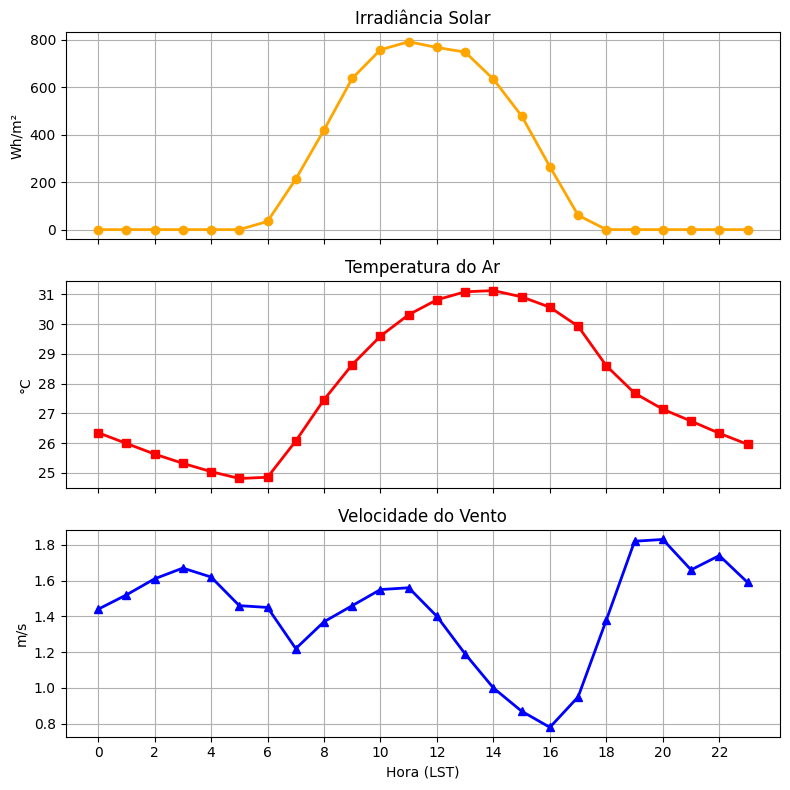

In [36]:
# ============================================================
# 04 - CONDIÇÕES AMBIENTAIS
# Dados meteorológicos obtidos da plataforma NASA POWER
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from io import BytesIO

# ------------------------------------------------------------
# 1. CARREGAMENTO DO ARQUIVO CSV
# ------------------------------------------------------------

print("Selecione o arquivo CSV obtido na plataforma NASA POWER.")
print('')
arquivo = files.upload()

nome_arquivo = next(iter(arquivo))

# O arquivo possui 11 linhas de cabeçalho antes dos dados
df = pd.read_csv(
    BytesIO(arquivo[nome_arquivo]),
    skiprows=11
)

# ------------------------------------------------------------
# 2. EXTRAÇÃO DAS VARIÁVEIS
# ------------------------------------------------------------

# Hora do dia
hora = df["HR"].to_numpy()

# Irradiância solar incidente (Wh/m²)
irradiancia = df["ALLSKY_SFC_SW_DWN"].to_numpy()

# Temperatura do ar (°C)
temperatura_ar = df["T2M"].to_numpy()

# Velocidade do vento (m/s)
vento = df["WS10M"].to_numpy()

# ------------------------------------------------------------
# 3. VERIFICAÇÃO DOS DADOS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CONDIÇÕES AMBIENTAIS")
print("=" * 60)

print(f"Arquivo carregado: {nome_arquivo}")
print(f"Data: {df['DY'].iloc[0]:02d}/{df['MO'].iloc[0]:02d}/{df['YEAR'].iloc[0]}")

print(f"Total de registros: {len(df)}")

print(f"Irradiância máxima: {irradiancia.max():.2f} Wh/m²")
print(f"Temperatura máxima: {temperatura_ar.max():.2f} °C")
print(f"Temperatura mínima: {temperatura_ar.min():.2f} °C")
print(f"Vento máximo: {vento.max():.2f} m/s")

# Verificação de dados ausentes
if (df[["ALLSKY_SFC_SW_DWN", "T2M", "WS10M"]] == -999).any().any():
    raise ValueError(
        "O arquivo contém valores ausentes (-999). "
        "Verifique os dados antes de prosseguir."
    )

print("\nVerificação concluída: dados carregados com sucesso.")

# ------------------------------------------------------------
# 4. VISUALIZAÇÃO DAS CONDIÇÕES AMBIENTAIS
# ------------------------------------------------------------

fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

# Irradiância solar
ax[0].plot(
    hora, irradiancia,
    'o-', color='orange', linewidth=2
)
ax[0].set_ylabel("Wh/m²")
ax[0].set_title("Irradiância Solar")
ax[0].grid(True)

# Temperatura do ar
ax[1].plot(
    hora, temperatura_ar,
    's-', color='red', linewidth=2
)
ax[1].set_ylabel("°C")
ax[1].set_title("Temperatura do Ar")
ax[1].grid(True)

# Velocidade do vento
ax[2].plot(
    hora, vento,
    '^-', color='blue', linewidth=2
)
ax[2].set_ylabel("m/s")
ax[2].set_xlabel("Hora (LST)")
ax[2].set_title("Velocidade do Vento")
ax[2].grid(True)

ax[2].set_xticks(np.arange(0, 24, 2))

plt.tight_layout()
plt.show()

## **5 - TRANSFERÊNCIA DE CALOR**

<div align="center"> <h3>A energia fornecida pelo ambiente é suficiente para explicar as temperaturas observadas durante o acidente?</h3> </div>

A evolução da temperatura do estireno é determinada por meio de um balanço global de energia, adotando-se o modelo de parâmetros concentrados (Lumped Capacitance Model), no qual a temperatura do líquido é assumida uniforme em todo o volume do tanque. Nesta primeira etapa, são considerados apenas o aquecimento pela radiação solar incidente e a troca de calor por convecção com o ar atmosférico.

Para o cálculo da convecção, utiliza-se a área lateral do tanque acrescida da área do teto, enquanto a radiação solar é aplicada sobre a área projetada do tanque. O fundo foi desconsiderado por estar em contato com a fundação, onde a transferência de calor ocorre predominantemente por condução com o solo.

Embora exista condução através da parede metálica, esse mecanismo foi desprezado nesta etapa devido à pequena espessura das chapas (6 a 14 mm) e à elevada condutividade térmica do aço ASTM A36, tornando sua resistência térmica muito inferior às resistências convectivas. Assim, admite-se que o calor absorvido pela parede seja rapidamente transferido ao estireno, sem comprometer a representação do comportamento térmico global do sistema.

Em etapas futuras, o modelo poderá ser ampliado para incluir radiação térmica, condução pela parede do tanque e o calor liberado pela polimerização do estireno.

Módulos seguintes:


* 5.1 Áreas de troca térmica

* 5.2 Massa de estireno

* 5.3 Radiação solar

* 5.4 Convecção

* 5.5 Exemplo didático da condução pela parede

* 5.6 Balanço de energia

* 5.7 Visualização

* 5.8 Discussão dos Resultados<br><br>

Os parâmetros editáveis da simulação térmica, incluindo a absortividade solar, o passo de tempo e a temperatura inicial do estireno, são definidos na célula de código a seguir.

TRANSFERÊNCIA DE CALOR

Modelo.................. Lumped Capacitance Model
Hipótese................ Temperatura uniforme no estireno

Mecanismos considerados
• Radiação solar......... Sim
• Convecção.............. Sim
• Condução............... Não (exemplo didático)
• Radiação térmica....... Não
• Polimerização.......... Não

Constantes
Absortividade (α)........ 0.60
Coef. convectivo......... Variável (McAdams)
h mínimo................ 8.66 W/(m².K)
h máximo................ 12.65 W/(m².K)
Temperatura inicial...... 26.35 °C
Passo de tempo........... 3600 s (1 hora)




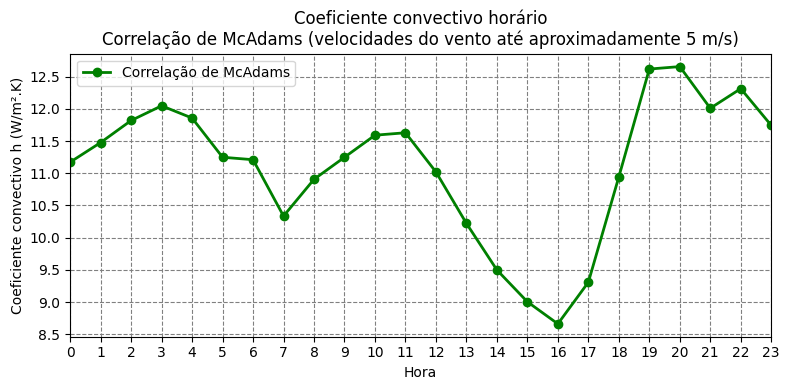

In [37]:
# ==========================================
# 5 - TRANSFERÊNCIA DE CALOR
# ==========================================

# ==========================================================
# >>> DADOS EDITÁVEIS PELO USUÁRIO <<<
# ==========================================================

# Absortividade solar da superfície do tanque
alpha = 0.60

# Passo de tempo da simulação
dt = 3600              # s (1 hora)

# Temperatura inicial do estireno
# Opções:
#   None: utiliza a temperatura do ar na primeira hora
#   Valor numérico: define uma temperatura inicial específica (°C)

TEMPERATURA_INICIAL = None

# ==========================================================
# >>> FIM DOS DADOS EDITÁVEIS <<<
# ==========================================================


# ============================================================
# CONFIGURAÇÃO DA TEMPERATURA INICIAL
# ============================================================

if TEMPERATURA_INICIAL is None:
    T_estireno = temperatura_ar[0]
else:
    T_estireno = TEMPERATURA_INICIAL


# ------------------------------------------------------------
# Coeficiente convectivo
# Correlação de McAdams: h = 5.7 + 3.8 V
# V : velocidade do vento (m/s)
# h : W/(m².K)
# ------------------------------------------------------------
h = 5.7 + 3.8 * vento


# Saída

print("="*60)
print("TRANSFERÊNCIA DE CALOR")
print("="*60)
print()
print("Modelo.................. Lumped Capacitance Model")
print("Hipótese................ Temperatura uniforme no estireno")

print()

print("Mecanismos considerados")
print(f"• Radiação solar......... Sim")
print(f"• Convecção.............. Sim")
print(f"• Condução............... Não (exemplo didático)")
print(f"• Radiação térmica....... Não")
print(f"• Polimerização.......... Não")

print()

print("Constantes")
print(f"Absortividade (α)........ {alpha:.2f}")
print(f"Coef. convectivo......... Variável (McAdams)")
print(f"h mínimo................ {h.min():.2f} W/(m².K)")
print(f"h máximo................ {h.max():.2f} W/(m².K)")
print(f"Temperatura inicial...... {T_estireno:.2f} °C")
print(f"Passo de tempo........... {dt:.0f} s ({dt/3600:.0f} hora)")

print("="*60)
print()
print()

# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(8,4))

plt.plot(
    hora,
    h,
    'o-',
    linewidth=2,
    color='green',
    label='Correlação de McAdams'
)

plt.xticks(np.arange(0,24,1))

plt.xlabel("Hora")
plt.ylabel("Coeficiente convectivo h (W/m².K)")

plt.title(
    "Coeficiente convectivo horário\n"
    "Correlação de McAdams (velocidades do vento até aproximadamente 5 m/s)"
)

# Grid principal
plt.grid(
    True,
    which='major',
    linestyle='--',
    linewidth=0.8,
    color='gray'
)

plt.xlim(0,23)

plt.legend()

plt.tight_layout()

plt.show()

### **5.1 - Áreas de troca térmica**

<div align="center"> <h3>Quais superfícies do reservatório participam das trocas de calor?</h3> </div>

Nesta etapa, são determinadas as áreas do tanque utilizadas no balanço de energia. A área lateral e a área superior (teto) são consideradas no cálculo da transferência de calor por convecção com o ambiente, enquanto a área projetada é utilizada para estimar a energia solar incidente sobre o tanque.

As áreas são calculadas a partir das dimensões geométricas definidas na seção 2 de caracterização do tanque, garantindo a consistência entre os parâmetros geométricos e o modelo térmico.

A célula a seguir calcula e apresenta as áreas consideradas na simulação.


In [38]:
# ============================================================
# 5.1 - Área de troca térmica
# ============================================================
# Áreas do tanque que participarão da transferência de calor

# Área lateral do tanque
A_lateral = tanque.area_lateral

# Área superior (teto)
A_topo = np.pi * tanque.raio**2

# Área total exposta
A_convectiva  = A_lateral + A_topo

# Área projetada para incidência solar
A_projetada = tanque.diametro * tanque.altura

print("="*60)
print("ÁREAS DE TROCA TÉRMICA")
print("="*60)
print("")
print(f"Área lateral    : {A_lateral:.2f} m²")
print(f"Área superior   : {A_topo:.2f} m²")
print(f"Área convectiva : {A_convectiva:.2f} m²")
print(f"Área projetada  : {A_projetada:.2f} m²")

ÁREAS DE TROCA TÉRMICA

Área lateral    : 1506.39 m²
Área superior   : 589.65 m²
Área convectiva : 2096.04 m²
Área projetada  : 479.50 m²


### 5.2 - Massa de estireno

<div align="center"> <h3>Como determinar a massa de estireno armazenada e qual sua influência no aquecimento do tanque?</h3> </div>

Para aplicar o balanço global de energia, é necessário determinar a massa de estireno armazenada no tanque, uma vez que a quantidade de matéria influencia diretamente sua capacidade de absorver calor.

A massa é calculada a partir do volume de líquido armazenado e de sua densidade, conforme a relação:

$$
m = \rho V
$$

em que \(m\) representa a massa de estireno (kg), \(\rho\) é sua densidade (kg/m³) e \(V\) corresponde ao volume de líquido armazenado (m³).

A célula de código a seguir realiza esse cálculo e apresenta o resultado em quilogramas e toneladas. O valor obtido será utilizado no balanço de energia da Seção 5.6.


In [39]:
# ============================================================
# 5.2 - Massa de estireno
# ============================================================
# Como o balanço de energia será aplicado ao líquido, precisamos da massa.
# Massa total de estireno armazenado no tanque

massa_estireno = tanque.volume_liquido * estireno.densidade

print("="*60)
print("Massa de Estireno ")
print("="*60)
print("")
print(f"Volume de estireno : {tanque.volume_liquido:.2f} m³")
print(f"Densidade          : {estireno.densidade:.2f} kg/m³")
print(f"Massa              : {massa_estireno:.0f} kg")
print(f"Massa              : {massa_estireno/1000:.0f} ton")

Massa de Estireno 

Volume de estireno : 9286.92 m³
Densidade          : 906.00 kg/m³
Massa              : 8413947 kg
Massa              : 8414 ton


### 5.3 – Radiação solar

Após determinar a massa de estireno armazenada no tanque, surge uma nova questão:

<div align="center"> <h3>Como a radiação solar contribui para o aquecimento do reservatório?</h3> </div>

Antes de responder a essa pergunta, é importante esclarecer outra dúvida:

<div align="center"> <h3>o modelo deve considerar a potência fornecida pela radiação solar ou a energia absorvida pelo tanque ao longo do tempo? </h3> </div>

Embora essas grandezas estejam relacionadas, elas possuem significados físicos distintos. A **potência térmica** representa a taxa com que a energia é transferida ao reservatório, sendo medida em watts (W). Já a **energia** corresponde ao total acumulado ao longo do tempo, sendo expressa em joules (J) ou, neste trabalho, em megawatt-hora (MWh).

Como o balanço global de energia descreve a evolução temporal da temperatura, a grandeza utilizada inicialmente é a potência térmica absorvida pela radiação solar, dada por

$$
\dot{Q}_{\mathrm{solar}}=\alpha G A_P,
$$

em que:

- $\alpha$ é a absortividade da superfície externa do tanque;
- $G$ é a irradiância solar global incidente obtida da plataforma NASA POWER;
- $A_P$ é a área projetada do reservatório.

Neste trabalho foi adotada uma absortividade igual a **0,60**, valor típico para superfícies metálicas pintadas.

A potência absorvida varia ao longo do dia porque a irradiância solar também varia. Entretanto, muitas vezes é mais intuitivo avaliar **quanta energia o tanque recebeu durante todo o período da simulação**. Essa energia é obtida pela integração da potência no tempo,

$$
Q_{\mathrm{solar}}
=
\dot{Q}_{\mathrm{solar}}\Delta t,
$$

em que $\Delta t=3600$ s corresponde ao intervalo de uma hora entre dois registros consecutivos dos dados meteorológicos.

No código a seguir, calcula-se inicialmente a **potência térmica horária absorvida** pelo reservatório e, posteriormente, integra-se essa potência para obter a **energia solar total** recebida durante o dia. Ao final, é apresentado um gráfico da potência absorvida, permitindo visualizar como ela acompanha diretamente a variação da irradiância solar.

### O que será observado?

Ao executar esta etapa da simulação, o estudante poderá acompanhar a seguinte sequência:

1. Obter a irradiância solar horária proveniente da plataforma NASA POWER;
2. Calcular a potência térmica absorvida pela superfície do tanque utilizando a equação
   $\dot{Q}_{\mathrm{solar}}=\alpha G A_P$;
3. Integrar numericamente essa potência ao longo do tempo;
4. Determinar a energia solar total absorvida durante o dia.

Essa sequência evidencia a diferença entre **potência** e **energia**, mostrando como uma equação física é implementada computacionalmente e como os dados meteorológicos são transformados em uma variável utilizada diretamente no balanço global de energia.

RADIAÇÃO SOLAR
Área projetada............. 479.50 m²
Absortividade.............. 0.60
Irradiância máxima......... 790.85 W/m²
Potência máxima absorvida.. 0.228 MW
Energia absorvida no dia... 1.67 MWh



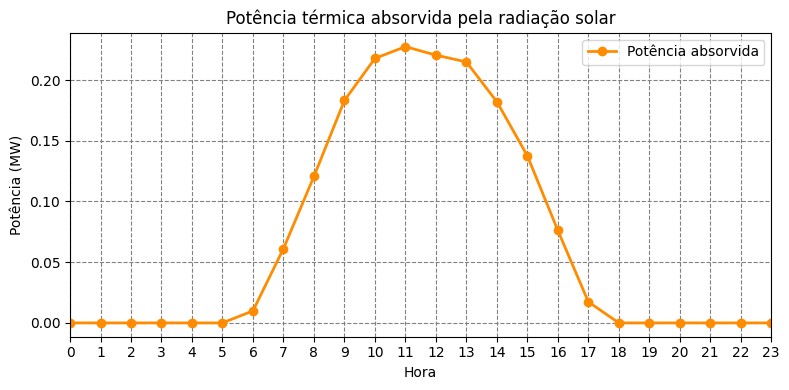

In [40]:
# ============================================================
# 5.3 - Radiação solar
# ============================================================
# Potência térmica absorvida pelo tanque
#
# Qdot_solar : potência (W)
# E_solar    : energia (MWh)
# ============================================================

# Potência térmica absorvida
Qdot_solar = alpha * irradiancia * A_projetada

print("="*55)
print("RADIAÇÃO SOLAR")
print("="*55)

print(f"Área projetada............. {A_projetada:.2f} m²")
print(f"Absortividade.............. {alpha:.2f}")

print(f"Irradiância máxima......... {irradiancia.max():.2f} W/m²")

print(f"Potência máxima absorvida.. {Qdot_solar.max()/1e6:.3f} MW")

print("="*55)

# ============================================================
# Energia absorvida durante o dia
# ============================================================

E_solar = np.sum(Qdot_solar) * dt / 3.6e9      # MWh

print(f"Energia absorvida no dia... {E_solar:.2f} MWh")

print("")

# ============================================================
# Potência térmica absorvida pela radiação solar
# ============================================================

plt.figure(figsize=(8,4))

plt.plot(
    hora,
    Qdot_solar/1e6,
    'o-',
    linewidth=2,
    color='darkorange',
    label='Potência absorvida'
)

plt.xticks(np.arange(0,24,1))

plt.xlim(0,23)

plt.grid(
    True,
    which='major',
    linestyle='--',
    linewidth=0.8,
    color='gray'
)

plt.xlabel("Hora")
plt.ylabel("Potência (MW)")

plt.title(
    "Potência térmica absorvida pela radiação solar"
)

plt.legend()

plt.tight_layout()

plt.show()

### 5.4 – Convecção

<div align="center"> <h3>Como representar a troca de calor entre o reservatório e o ar atmosférico?</h3> </div>

A convecção representa a transferência de energia térmica entre a
superfície externa do reservatório e o ar atmosférico. Diferentemente
da radiação solar, essa transferência pode ocorrer nos dois sentidos:
o ar pode fornecer energia ao tanque ou o tanque pode perder energia
para o ambiente.

A potência térmica convectiva é descrita pela Lei de Resfriamento de
Newton:

$$
\dot{Q}_{\mathrm{conv}}
=
hA_{\mathrm{conv}}
\left(T_{\mathrm{ar}}-T_{\mathrm{est}}\right),
$$

em que:

- $\dot{Q}_{\mathrm{conv}}$ é a potência térmica convectiva (W);
- $h$ é o coeficiente convectivo (W/m²·K);
- $A_{\mathrm{conv}}$ é a área de troca térmica (m²);
- $T_{\mathrm{ar}}$ é a temperatura do ar (°C);
- $T_{\mathrm{est}}$ é a temperatura instantânea do estireno (°C).

O sinal da potência possui significado físico. Quando
$T_{\mathrm{ar}}>T_{\mathrm{est}}$, a potência é positiva e o ar
fornece energia ao tanque. Quando
$T_{\mathrm{ar}}<T_{\mathrm{est}}$, a potência é negativa e representa
uma perda de energia do tanque para o ambiente.

<div align="center"> <h3>Uma nova questão surge naturalmente: como determinar o coeficiente convectivo h(t)?</h3> </div>

Como esse coeficiente depende das condições de escoamento do ar sobre a superfície externa do reservatório, adotou-se a correlação empírica proposta por McAdams para convecção forçada sobre superfícies externas

Para o coeficiente convectivo será utilizada a correlação de McAdams,

$$
h=5{,}7+3{,}8v,
$$

em que $v$ é a velocidade do vento em m/s. A área de troca será
aproximada pela soma da área lateral e da área do teto,

$$
A_{\mathrm{conv}}
=
A_{\mathrm{lateral}}+A_{\mathrm{topo}}.
$$

Como a temperatura do estireno varia ao longo da simulação, a potência
convectiva não é constante. Ela será recalculada a cada passo de tempo,
utilizando a temperatura instantânea do líquido e as condições
meteorológicas correspondentes.

A energia transferida por convecção durante um intervalo de tempo é
obtida pela integração da potência:

$$
E_{\mathrm{conv}}
=
\int_{t_1}^{t_2}
\dot{Q}_{\mathrm{conv}}(t)\,dt.
$$

Para um passo de tempo constante, pode-se utilizar a aproximação:

$$
\Delta E_{\mathrm{conv}}
\approx
\dot{Q}_{\mathrm{conv}}\Delta t.
$$

In [41]:
# ============================================================
# 5.4 - Convecção
# ============================================================
# Transferência de calor entre o tanque e o ar ambiente

# ------------------------------------------------------------
# Coeficiente convectivo de McAdams - h[W/(m².K)]
# ------------------------------------------------------------

h = 5.7 + 3.8 * vento

# ------------------------------------------------------------
# Área sujeita à convecção
# ------------------------------------------------------------

A_conv = A_lateral + A_topo

# ------------------------------------------------------------
# Resultados preliminares
# ------------------------------------------------------------

print("="*60)
print("CONVECÇÃO")
print("="*60)

print(f"Área lateral............... {A_lateral:.2f} m²")
print(f"Área do topo............... {A_topo:.2f} m²")
print(f"Área de convecção.......... {A_conv:.2f} m²")

print()

print(f"h mínimo................... {h.min():.2f} W/(m².K)")
print(f"h médio.................... {h.mean():.2f} W/(m².K)")
print(f"h máximo................... {h.max():.2f} W/(m².K)")

print()

print("A potência convectiva será")
print("calculada dentro do balanço temporal.")

# ------------------------------------------------------------
# Explicação física para o usuário
# ------------------------------------------------------------

print()
print("INTERPRETAÇÃO FÍSICA")
print("-"*60)

print(
    "A convecção representa a transferência de energia térmica "
    "entre a superfície externa do tanque e o ar ambiente."
)

print()
print("Lei de Resfriamento de Newton:")
print()
print("Q_dot_conv = h * A_conv * (T_ar - T_est)")

print()
print(
    "Nessa expressão, h é o coeficiente convectivo, A_conv é a "
    "área de troca térmica, T_ar é a temperatura do ar e T_est "
    "é a temperatura do estireno."
)

print()
print(
    "A potência convectiva será calculada posteriormente, "
    "dentro do balanço temporal, pois a temperatura do estireno "
    "(T_est) varia durante a simulação."
)

print()
print(
    "Assim, o h e a A_conv são determinados nesta etapa, "
    "enquanto Q_dot_conv será atualizado a cada instante do balanço energético."
)

print("="*60)

CONVECÇÃO
Área lateral............... 1506.39 m²
Área do topo............... 589.65 m²
Área de convecção.......... 2096.04 m²

h mínimo................... 8.66 W/(m².K)
h médio.................... 11.11 W/(m².K)
h máximo................... 12.65 W/(m².K)

A potência convectiva será
calculada dentro do balanço temporal.

INTERPRETAÇÃO FÍSICA
------------------------------------------------------------
A convecção representa a transferência de energia térmica entre a superfície externa do tanque e o ar ambiente.

Lei de Resfriamento de Newton:

Q_dot_conv = h * A_conv * (T_ar - T_est)

Nessa expressão, h é o coeficiente convectivo, A_conv é a área de troca térmica, T_ar é a temperatura do ar e T_est é a temperatura do estireno.

A potência convectiva será calculada posteriormente, dentro do balanço temporal, pois a temperatura do estireno (T_est) varia durante a simulação.

Assim, o h e a A_conv são determinados nesta etapa, enquanto Q_dot_conv será atualizado a cada instante do balanço 

### 5.5 – Exemplo didático da condução pela parede

<div align="center"> <h3>A parede metálica do reservatório impõe uma resistência significativa à transferência de calor para o estireno?</h3> </div>

Embora a condução através da parede não tenha sido incorporada ao balanço global
de energia, sua influência foi analisada por meio de um exemplo didático baseado na Lei de Fourier. A condução representa a transferência de calor através da parede metálica do tanque, transportando a energia térmica da superfície externa, aquecida pela radiação solar e pela convecção com o ar ambiente, até a superfície interna em contato com o estireno.

Esse mecanismo é descrito pela Lei de Fourier,

$$
\dot Q_{cond}
=
kA
\frac{\Delta T}{L},
$$

em que:

- $k$ é a condutividade térmica do aço ASTM A36;
- $A$ é a área de condução;
- $L$ é a espessura da parede;
- $\Delta T$ é a diferença de temperatura entre as faces da chapa.

Como o aço apresenta elevada condutividade térmica e as chapas do reservatório possuem espessuras entre 6 e 14 mm, espera-se que a resistência térmica da parede seja muito pequena.

Neste exemplo, utiliza-se o fluxo de calor calculado nas etapas anteriores para estimar qual diferença de temperatura seria necessária para conduzir esse calor através da parede metálica. O objetivo não é incorporar a condução ao balanço principal de energia, mas verificar se a resistência térmica da parede pode ser desprezada na modelagem.

### O que será observado?

Ao executar esta etapa da simulação, o estudante poderá:

1. calcular a potência térmica que atravessa a parede do tanque;
2. aplicar a Lei de Fourier;
3. estimar a diferença de temperatura entre as faces da chapa;
4. verificar se essa diferença é suficientemente pequena para justificar a simplificação adotada no modelo.

Caso a diferença de temperatura obtida seja da ordem de centésimos de grau Celsius, conclui-se que a parede praticamente não limita a transferência de calor entre o ambiente externo e o estireno.

EXEMPLO DIDÁTICO - CONDUÇÃO ATRAVÉS DA PAREDE
Condutividade térmica....... 50.0 W/(m.K)
Espessura média............. 9.4 mm
Área de condução............ 1506.39 m²

=== Potência solar utilizada como referência ===
Mínima...................... 0.00 kW
Média....................... 69.55 kW
Máxima...................... 227.53 kW

=== Potência conduzida estimada ===
Mínima...................... 0.00 kW
Média....................... 69.55 kW
Máxima...................... 227.53 kW

=== Diferença de temperatura na parede ===
ΔT mínimo................... 0.00000 °C
ΔT máximo................... 0.02848 °C
|ΔT| máximo................. 0.02848 °C


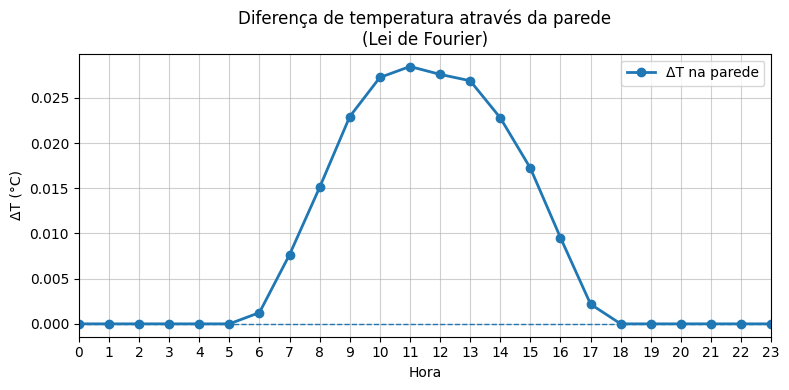

In [42]:
# ============================================================
# 5.5 - Exemplo didático da condução através da parede
# ============================================================
# Objetivo:
# Estimar a diferença de temperatura entre as faces da parede
# metálica utilizando a Lei de Fourier.
#
# A condução NÃO participa do balanço principal de energia.
# Este cálculo é apenas ilustrativo e independente do cálculo
# da convecção.
#
# Para estimar a ordem de grandeza da resistência térmica da
# parede, utiliza-se a potência solar absorvida como referência.
#
# ============================================================

# ------------------------------------------------------------
# Propriedades da parede
# ------------------------------------------------------------

# ==========================================================
# >>> DADOS EDITÁVEIS PELO USUÁRIO <<<
# ==========================================================

# Condutividade térmica aproximada do aço ASTM A36
k = 50.0                  # W/(m.K)

# ==========================================================
# >>> FIM DOS DADOS EDITÁVEIS <<<
# ==========================================================

# Espessura média da parede
L = np.mean(tanque.espessuras)

# Área de condução através do costado
A_cond = tanque.area_lateral


# ------------------------------------------------------------
# Potência utilizada como referência para a condução
# ------------------------------------------------------------
#
# Para evitar circularidade com o balanço global, a potência
# convectiva NÃO é utilizada neste cálculo.
#
# A potência solar absorvida pelo reservatório é utilizada
# como referência para estimar a ordem de grandeza da potência
# que atravessaria a parede.
#
# Qdot_cond ≈ Qdot_rad_solar
#
# ------------------------------------------------------------

Qdot_cond = Qdot_solar.copy()


# ------------------------------------------------------------
# Lei de Fourier para uma parede plana
# ------------------------------------------------------------
#
# Qdot_cond = k * A_cond * ΔT / L
#
# Portanto:
#
# ΔT = Qdot_cond * L / (k * A_cond)
#
# O sinal de ΔT acompanha o sentido da transferência de calor.
# Neste caso, como Qdot_solar >= 0, a diferença representa a
# diferença de temperatura necessária para conduzir a potência
# solar de referência através da parede.
# ------------------------------------------------------------

deltaT_parede = (
    Qdot_cond
    * L
    /
    (k * A_cond)
)


# ------------------------------------------------------------
# Módulo da diferença de temperatura
# ------------------------------------------------------------
#
# Representa apenas a intensidade da diferença de temperatura
# entre as faces da parede.
# ------------------------------------------------------------

deltaT_parede_abs = np.abs(deltaT_parede)


# ============================================================
# Resultados
# ============================================================

print("="*60)
print("EXEMPLO DIDÁTICO - CONDUÇÃO ATRAVÉS DA PAREDE")
print("="*60)

print(f"Condutividade térmica....... {k:.1f} W/(m.K)")
print(f"Espessura média............. {L*1000:.1f} mm")
print(f"Área de condução............ {A_cond:.2f} m²")

print()

print("=== Potência solar utilizada como referência ===")
print(f"Mínima...................... "
      f"{Qdot_solar.min()/1000:.2f} kW")
print(f"Média....................... "
      f"{Qdot_solar.mean()/1000:.2f} kW")
print(f"Máxima...................... "
      f"{Qdot_solar.max()/1000:.2f} kW")

print()

print("=== Potência conduzida estimada ===")
print(f"Mínima...................... "
      f"{Qdot_cond.min()/1000:.2f} kW")
print(f"Média....................... "
      f"{Qdot_cond.mean()/1000:.2f} kW")
print(f"Máxima...................... "
      f"{Qdot_cond.max()/1000:.2f} kW")

print()

print("=== Diferença de temperatura na parede ===")
print(f"ΔT mínimo................... "
      f"{deltaT_parede.min():.5f} °C")
print(f"ΔT máximo................... "
      f"{deltaT_parede.max():.5f} °C")
print(f"|ΔT| máximo................. "
      f"{deltaT_parede_abs.max():.5f} °C")

print("="*60)


# ============================================================
# Gráfico da diferença de temperatura através da parede
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(
    hora,
    deltaT_parede,
    "o-",
    linewidth=2,
    label="ΔT na parede"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.grid(True, alpha=0.6, linewidth=0.8)

plt.xticks(np.arange(0, 24, 1))
plt.xlim(0, 23)

plt.xlabel("Hora")
plt.ylabel("ΔT (°C)")

plt.title(
    "Diferença de temperatura através da parede\n"
    "(Lei de Fourier)"
)

plt.legend()
plt.tight_layout()
plt.show()

### 5.6 – Balanço de Energia

<div align="center"> <h3>Como combinar os diferentes mecanismos de transferência de calor para estimar a temperatura do líquido ao longo do tempo?</h3> </div>

Os mecanismos de transferência de calor descritos nas seções anteriores são reunidos por meio do balanço global de energia, que representa a conservação da energia aplicada ao estireno armazenado no tanque. A cada passo de tempo, os fluxos de calor provenientes da radiação solar, da convecção com o ar atmosférico e, futuramente, da condução através da parede são somados para determinar a taxa de variação da temperatura do líquido.

O balanço global de energia é descrito por:

$$
mC_p\frac{dT}{dt}=Q_{total}
$$

onde

$$
Q_{total}=Q_{solar}+Q_{conv}+Q_{cond}
$$

sendo:

- $m$ a massa de estireno (kg);
- $C_p$ o calor específico do estireno (J/kg·K);
- $Q_{solar}$ o fluxo de calor devido à radiação solar (W);
- $Q_{conv}$ o fluxo de calor por convecção com o ar (W);
- $Q_{cond}$ o fluxo de calor por condução através da parede do tanque (W).

Nesta primeira implementação, a equação diferencial é resolvida numericamente utilizando um passo de tempo de **1 hora**, correspondente à resolução temporal dos dados meteorológicos obtidos na plataforma NASA POWER. A cada passo da simulação, os fluxos de calor são recalculados e a temperatura do estireno é atualizada, permitindo acompanhar sua evolução ao longo do dia. Nesta primeira implementação, a taxa de calor por condução através da parede não será utilizada no balanço global de energia. Portanto, considera-se, neste momento, que a contribuição da condução é desprezada no cálculo da temperatura do estireno.

In [43]:
# ============================================================
# 5.6 - Balanço Global de Energia
# ============================================================

# ------------------------------------------------------------
# Propriedades térmicas
# ------------------------------------------------------------
# ==========================================================
# >>> DADOS EDITÁVEIS PELO USUÁRIO <<<
# ==========================================================

Cp_aco = 490.0          # J/(kg.K)

# ==========================================================
# >>> FIM DOS DADOS EDITÁVEIS <<<
# ==========================================================

massa_casco = tanque.massa_shell()

capacidade_termica = (
    massa_estireno * Cp_estireno
    +
    massa_casco * Cp_aco
)

# ------------------------------------------------------------
# Vetores
# ------------------------------------------------------------

T_est = np.zeros(len(hora))

Qdot_solar = np.zeros(len(hora))
Qdot_conv = np.zeros(len(hora))
Qdot_total = np.zeros(len(hora))

# Energia acumulada em cada mecanismo
E_solar_acum = np.zeros(len(hora))
E_conv_acum = np.zeros(len(hora))
E_total_acum = np.zeros(len(hora))

# ------------------------------------------------------------
# Condição inicial
# ------------------------------------------------------------
# Inicialmente, o estireno encontra-se em equilíbrio térmico
# com o ar ambiente.
# ------------------------------------------------------------

T_est[0] = temperatura_ar[0]

# ------------------------------------------------------------
# Integração temporal
# ------------------------------------------------------------

for i in range(len(hora)):

    # --------------------------------------------------------
    # 1. Potência solar absorvida
    # --------------------------------------------------------

    Qdot_solar[i] = (
        alpha
        * irradiancia[i]
        * A_projetada
    )

    # --------------------------------------------------------
    # 2. Potência convectiva
    # --------------------------------------------------------
    # Lei de Resfriamento de Newton
    #
    # Q_dot_conv = h A (T_ar - T_est)
    #
    # O resultado é uma potência em watts.
    # --------------------------------------------------------

    Qdot_conv[i] = (
        h[i]
        * A_conv
        * (temperatura_ar[i] - T_est[i])
    )

    # --------------------------------------------------------
    # 3. Potência térmica resultante
    # --------------------------------------------------------

    Qdot_total[i] = (
        Qdot_solar[i]
        +
        Qdot_conv[i]
    )

    # --------------------------------------------------------
    # 4. Energia acumulada
    # --------------------------------------------------------
    # Para o primeiro instante, a energia acumulada é zero.
    # A partir dos demais instantes, integra-se numericamente
    # a potência pelo método do retângulo.
    # --------------------------------------------------------

    if i > 0:

        E_solar_acum[i] = (
            E_solar_acum[i-1]
            +
            Qdot_solar[i-1] * dt
        )

        E_conv_acum[i] = (
            E_conv_acum[i-1]
            +
            Qdot_conv[i-1] * dt
        )

        E_total_acum[i] = (
            E_total_acum[i-1]
            +
            Qdot_total[i-1] * dt
        )

    # --------------------------------------------------------
    # 5. Atualização da temperatura
    # --------------------------------------------------------
    # Não é necessário atualizar a temperatura depois do
    # último instante, pois não existe um instante seguinte.
    # --------------------------------------------------------

    if i < len(hora) - 1:

        dT = (
            Qdot_total[i]
            * dt
            /
            capacidade_termica
        )

        T_est[i+1] = T_est[i] + dT

# ------------------------------------------------------------
# Conversão das energias para MWh
# ------------------------------------------------------------

E_solar = E_solar_acum[-1] / 3.6e9
E_conv = E_conv_acum[-1] / 3.6e9
E_total = E_total_acum[-1] / 3.6e9

# ============================================================
# Resultados
# ============================================================

print("="*60)
print("BALANÇO GLOBAL DE ENERGIA")
print("="*60)

print(f"Temperatura inicial........ {T_est[0]:.2f} °C")
print(f"Temperatura final.......... {T_est[-1]:.2f} °C")

print()

print(f"Potência solar máxima...... {Qdot_solar.max()/1000:.2f} kW")
print(f"Potência solar média....... {Qdot_solar.mean()/1000:.2f} kW")

print()

print(f"Potência convectiva mínima. {Qdot_conv.min()/1000:.2f} kW")
print(f"Potência convectiva média.. {Qdot_conv.mean()/1000:.2f} kW")
print(f"Potência convectiva máxima. {Qdot_conv.max()/1000:.2f} kW")

print()

print(f"Potência total máxima...... {Qdot_total.max()/1000:.2f} kW")
print(f"Potência total média....... {Qdot_total.mean()/1000:.2f} kW")

print()

print(f"Energia solar.............. {E_solar:.3f} MWh")
print(f"Energia por convecção...... {E_conv:.3f} MWh")
print(f"Energia total.............. {E_total:.3f} MWh")

print()

print(f"Variação de temperatura.... "
      f"{T_est[-1] - T_est[0]:.4f} °C")

print()

print(f"Massa de estireno.......... "
      f"{massa_estireno/1000:.1f} t")

print(f"Massa do casco............. "
      f"{massa_casco/1000:.1f} t")

print(f"Capacidade térmica......... "
      f"{capacidade_termica/1e9:.3f} GJ/K")

print("="*60)

BALANÇO GLOBAL DE ENERGIA
Temperatura inicial........ 26.35 °C
Temperatura final.......... 26.91 °C

Potência solar máxima...... 227.53 kW
Potência solar média....... 69.55 kW

Potência convectiva mínima. -35.82 kW
Potência convectiva média.. 24.89 kW
Potência convectiva máxima. 98.07 kW

Potência total máxima...... 320.75 kW
Potência total média....... 94.44 kW

Energia solar.............. 1.669 MWh
Energia por convecção...... 0.621 MWh
Energia total.............. 2.290 MWh

Variação de temperatura.... 0.5642 °C

Massa de estireno.......... 8413.9 t
Massa do casco............. 111.5 t
Capacidade térmica......... 14.611 GJ/K


5.6.1 - Visualização do balanço global da evolução da temperatura do estireno

Nesta etapa, são apresentados os resultados do balanço global de energia (5.6), permitindo visualizar a evolução da temperatura do estireno e compará-la com a temperatura do ar. Os gráficos também mostram as contribuições individuais da radiação solar e da convecção, tanto em termos de potência térmica instantânea quanto de energia acumulada ao longo do período simulado.

A análise dessas curvas permite identificar os períodos de aquecimento e resfriamento, avaliar a influência de cada mecanismo de transferência de calor e investigar se a energia fornecida pelo ambiente é suficiente para explicar as temperaturas observadas durante o acidente.


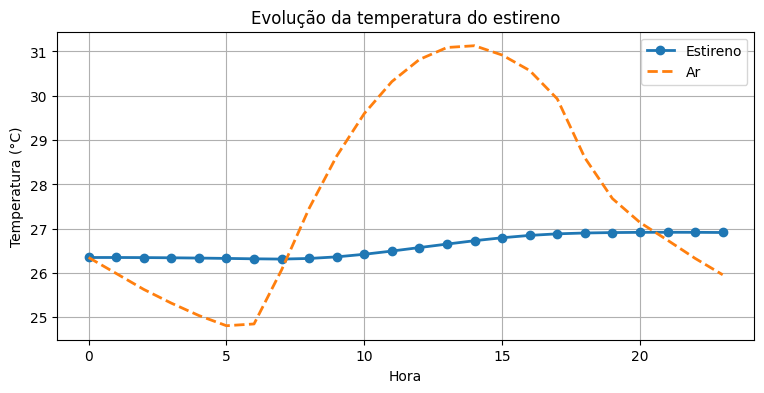

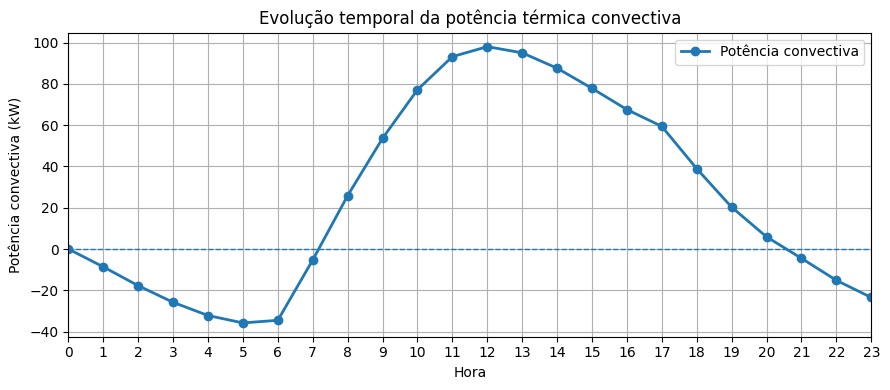

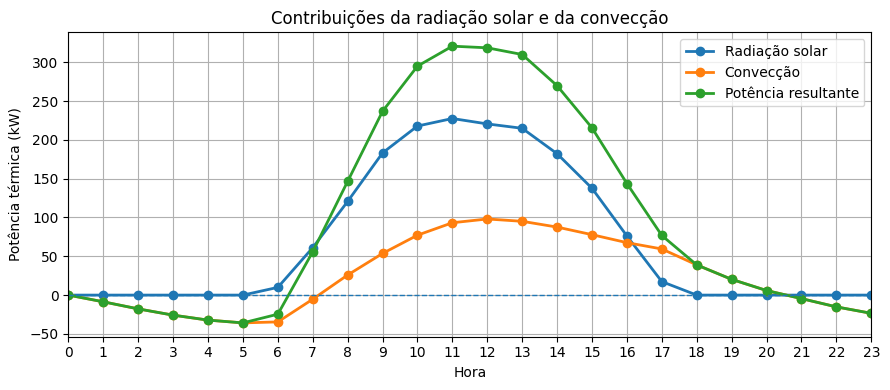

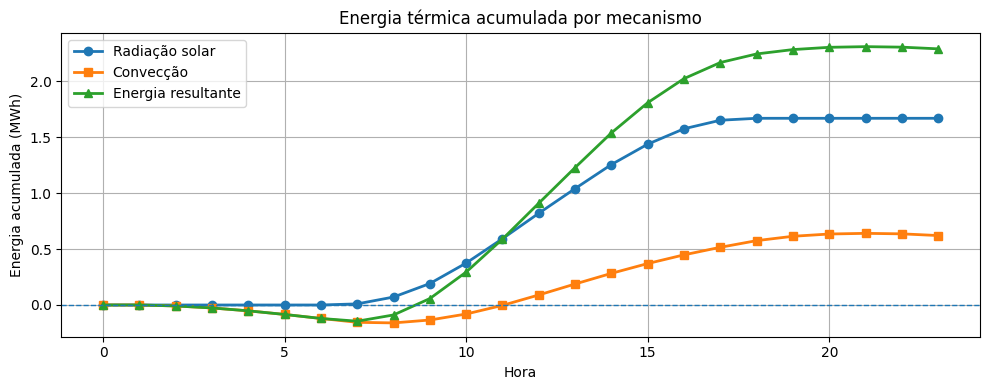

In [44]:
# =============================================================================
# 5.6.1 - Visualização do balanço global da evolução da temperatura do estireno
# =============================================================================

plt.figure(figsize=(9,4))

plt.plot(
    hora,
    T_est,
    '-o',
    linewidth=2,
    label="Estireno"
)

plt.plot(
    hora,
    temperatura_ar,
    '--',
    linewidth=2,
    label="Ar"
)

plt.xlabel("Hora")

plt.ylabel("Temperatura (°C)")

plt.title("Evolução da temperatura do estireno")

plt.grid(True)

plt.legend()

plt.show()

print("")
print("")

# ============================================================
# Gráfico da potência térmica convectiva
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(
    hora,
    Qdot_conv / 1000,
    "o-",
    linewidth=2,
    label="Potência convectiva"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xticks(np.arange(0, 24, 1))
plt.xlim(0, 23)

plt.xlabel("Hora")
plt.ylabel("Potência convectiva (kW)")

plt.title(
    "Evolução temporal da potência térmica convectiva"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("")
print("")

# ============================================================
# Comparação entre as potências solar e convectiva
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(
    hora,
    Qdot_solar / 1000,
    "o-",
    linewidth=2,
    label="Radiação solar"
)

plt.plot(
    hora,
    Qdot_conv / 1000,
    "o-",
    linewidth=2,
    label="Convecção"
)

plt.plot(
    hora,
    Qdot_total / 1000,
    "o-",
    linewidth=2,
    label="Potência resultante"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xticks(np.arange(0, 24, 1))
plt.xlim(0, 23)

plt.xlabel("Hora")
plt.ylabel("Potência térmica (kW)")

plt.title(
    "Contribuições da radiação solar e da convecção"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("")
print("")

# ============================================================
# Comparação completa das energias acumuladas
# ============================================================

plt.figure(figsize=(10, 4))

plt.plot(
    hora,
    E_solar_acum / 3.6e9,
    "o-",
    linewidth=2,
    label="Radiação solar"
)

plt.plot(
    hora,
    E_conv_acum / 3.6e9,
    "s-",
    linewidth=2,
    label="Convecção"
)

plt.plot(
    hora,
    E_total_acum / 3.6e9,
    "^-",
    linewidth=2,
    label="Energia resultante"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Hora")
plt.ylabel("Energia acumulada (MWh)")

plt.title(
    "Energia térmica acumulada por mecanismo"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 6 – Evaporação

Na seção anterior foi determinada a evolução da temperatura do estireno por meio do balanço global de energia. Entretanto, durante o acidente ocorrido em Manaus, estimou-se que a temperatura média do líquido atingiu aproximadamente **72 °C**, valor muito superior ao previsto apenas pela ação da radiação solar e da convecção.

Surge então uma nova questão:

<div align="center"> <h3>Qual é a ordem de grandeza da energia associada à vaporização do estireno quando o reservatório atinge temperaturas elevadas?</h3> </div>

Conhecendo essa energia, é possível responder outra pergunta importante:

<div align="center"> <h3>Qual pressão seria desenvolvida caso esse vapor permanecesse confinado no interior do reservatório?</h3> </div>

Embora essa hipótese represente um limite superior (situação extrema), ela estabelece uma estimativa física para a quantidade máxima de vapor que poderia ser produzida e fornece a base para a próxima etapa do simulador, dedicada à análise da pressão interna do reservatório.

EVAPORAÇÃO
Temperatura inicial........ 26.35 °C
Temperatura final.......... 72.00 °C

Variação de temperatura.... 45.65 °C

Capacidade térmica do sistema ......... 14.6108 GJ/K
Energia de aquecimento acumulada.......... 666.98 GJ
Calor latente.............. 339.0 kJ/kg
Massa máxima teoricamente evaporável............... 1967496 kg
Fração máxima evaporável... 23.38 %

OBSERVAÇÃO: a massa calculada representa um limite energético teórico e não a massa efetivamente evaporada durante o acidente.


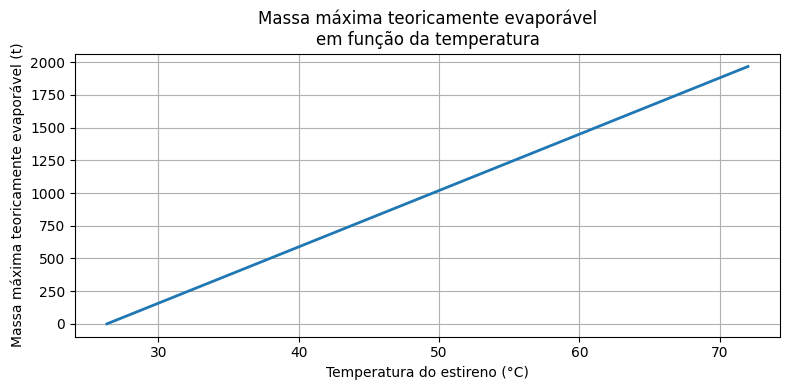

In [45]:
# ============================================================
# 6 - Evaporação
# ============================================================

# ==========================================================
# >>> DADOS EDITÁVEIS PELO USUÁRIO <<<
# ==========================================================

# ------------------------------------------------------------
# Temperatura do acidente
# ------------------------------------------------------------

# Temperatura inicial obtida no balanço global de energia
T_inicial = 26.35             # °C

# Temperatura média estimada durante o acidente
T_final = 72.0                # °C


# ------------------------------------------------------------
# Calor específico do casco
# ------------------------------------------------------------

# Calor específico aproximado do aço ASTM A36
Cp_aco = 490.0                # J/(kg.K)

# ------------------------------------------------------------
# Calor latente de vaporização do estireno
# ------------------------------------------------------------
Lv = 3.39e5                  # J/kg

# ==========================================================
# >>> FIM DOS DADOS EDITÁVEIS <<<
# ==========================================================

# ------------------------------------------------------------
# Massa do casco
# ------------------------------------------------------------

massa_casco = tanque.massa_shell()


# ------------------------------------------------------------
# Capacidade térmica total do sistema [J/K]
# ------------------------------------------------------------
#
# O sistema é considerado como: estireno + casco metálico

capacidade_termica = (
    massa_estireno * Cp_estireno
    +
    massa_casco * Cp_aco
)


# ------------------------------------------------------------
# Variação de temperatura
# ------------------------------------------------------------

deltaT = T_final - T_inicial


# ------------------------------------------------------------
# Energia necessária para aquecer o sistema
# ------------------------------------------------------------
#
# Q_aquecimento = C_total * ΔT
#
# Essa é a energia necessária para elevar a temperatura
# do conjunto formado pelo estireno e pelo casco metálico
# de T_inicial até T_final.
#
# IMPORTANTE:
# Essa energia NÃO é considerada como energia disponível
# simultaneamente para evaporação.
#
# Ela será utilizada apenas como referência para construir
# um cenário-limite de vaporização.
# ------------------------------------------------------------

Q_aquecimento = (
    capacidade_termica
    *
    deltaT
)


# ------------------------------------------------------------
# Massa máxima teoricamente evaporável
# ------------------------------------------------------------
#
# Hipótese-limite:
#
# Toda a energia calculada para aquecer o sistema fosse
# destinada exclusivamente à vaporização do estireno.
#
#     Q_ev = m_ev * Lv
#
# Portanto:
#
#     m_ev,max = Q_aquecimento / Lv
#
# O resultado NÃO representa a massa efetivamente evaporada.
# ------------------------------------------------------------

massa_evaporavel_max = (
    Q_aquecimento
    /
    Lv
)


# ============================================================
# Resultados
# ============================================================

print("="*60)
print("EVAPORAÇÃO")
print("="*60)

print(f"Temperatura inicial........ {T_inicial:.2f} °C")
print(f"Temperatura final.......... {T_final:.2f} °C")

print()

print(f"Variação de temperatura.... {deltaT:.2f} °C")

print()

print(
    f"Capacidade térmica do sistema ......... "
    f"{capacidade_termica/1e9:.4f} GJ/K"
)

print(
    f"Energia de aquecimento acumulada.......... "
    f"{Q_aquecimento/1e9:.2f} GJ"
)

print(
    f"Calor latente.............. "
    f"{Lv/1000:.1f} kJ/kg"
)

print(
    f"Massa máxima teoricamente evaporável............... "
    f"{massa_evaporavel_max:.0f} kg"
)

print(
    f"Fração máxima evaporável... "
    f"{100*massa_evaporavel_max/massa_estireno:.2f} %"
)

print()

print(
    "OBSERVAÇÃO: a massa calculada representa um limite "
    "energético teórico e não a massa efetivamente evaporada "
    "durante o acidente."
)

print("="*60)


# ============================================================
# Massa máxima teoricamente evaporável em função da
# temperatura
# ============================================================

# Intervalo de temperaturas utilizado na análise
temperatura = np.linspace(
    T_inicial,
    T_final,
    100
)


# ------------------------------------------------------------
# Energia necessária para aquecer o sistema em cada
# temperatura
# ------------------------------------------------------------

energia = (
    capacidade_termica
    *
    (temperatura - T_inicial)
)


# ------------------------------------------------------------
# Massa máxima teoricamente evaporável para cada temperatura
# ------------------------------------------------------------

massa_evaporavel_max_T = (
    energia
    /
    Lv
)


# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(
    temperatura,
    massa_evaporavel_max_T / 1000,
    linewidth=2
)

plt.grid(True)

plt.xlabel(
    "Temperatura do estireno (°C)"
)

plt.ylabel(
    "Massa máxima teoricamente evaporável (t)"
)

plt.title(
    "Massa máxima teoricamente evaporável\n"
    "em função da temperatura"
)

plt.tight_layout()

plt.show()

# 7 – Pressão interna

Na seção anterior foi estimada a quantidade máxima de estireno que poderia ser vaporizada caso toda a energia necessária para elevar a temperatura do sistema até aproximadamente **72 °C** fosse utilizada na mudança de fase.

Surge então uma nova questão:

<div align="center"> <h3>Qual pressão seria desenvolvida caso esse vapor permanecesse confinado no interior do reservatório?</h3> </div>

Essa pergunta é fundamental para compreender por que reservatórios aquecidos podem sofrer deformações estruturais ou até mesmo romper.

Para responder a essa questão, será adotado inicialmente um modelo simplificado baseado na **Lei dos Gases Ideais**,

\[
PV=nRT,
\]

em que:

- \(P\) é a pressão absoluta (Pa);
- \(V\) é o volume ocupado pelo vapor (m³);
- \(n\) é o número de mols de estireno evaporado;
- \(R\) é a constante universal dos gases;
- \(T\) é a temperatura absoluta (K).

Nesta etapa considera-se que:

- todo o vapor permanece confinado no espaço livre do tanque;
- o comportamento do vapor pode ser aproximado por um gás ideal;
- a temperatura do vapor é igual à temperatura média do estireno.

Embora essas hipóteses simplifiquem o fenômeno físico, elas permitem compreender como a formação de vapor influencia diretamente a pressão interna do reservatório.

Ao final desta etapa serão determinados:

1. o número de mols de estireno evaporado;
2. o volume disponível para o vapor;
3. a pressão absoluta;
4. a pressão manométrica do tanque.

Esses resultados servirão de base para a próxima seção, dedicada à análise da integridade estrutural do reservatório.

PRESSÃO INTERNA
Massa evaporada........ 1967.5 t
Volume de vapor........ 1031.9 m³
Número de mols......... 1.889e+07 mol

Temperatura............ 345.15 K

Pressão absoluta....... 52.534 MPa
Pressão manométrica.... 52.433 MPa


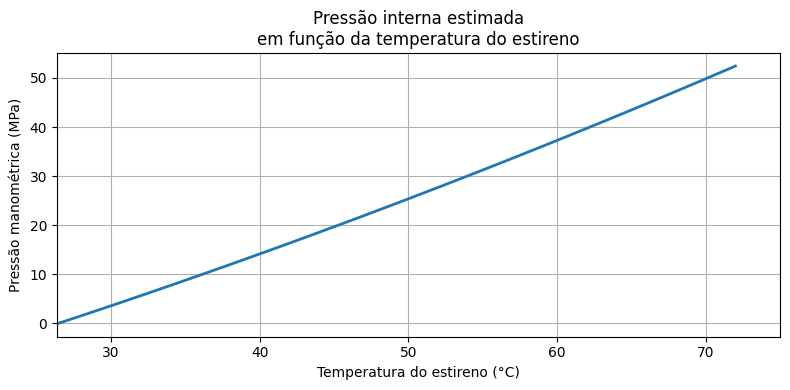

In [46]:
# ============================================================
# 7 - Pressão interna
# ============================================================
# Modelo simplificado
#
# Lei dos Gases Ideais
#
# PV = nRT
# ============================================================

# ------------------------------------------------------------
# Dados
# ------------------------------------------------------------

R = 8.314          # J/(mol.K)

M_estireno = 104.15e-3      # kg/mol

T_vapor = 72 + 273.15       # K

# ------------------------------------------------------------
# Volume disponível ao vapor
# ------------------------------------------------------------

V_vapor = tanque.volume_vapor

# ------------------------------------------------------------
# Número de mols
# ------------------------------------------------------------

n = massa_evaporavel_max / M_estireno

# ------------------------------------------------------------
# Pressão absoluta
# ------------------------------------------------------------

P = n * R * T_vapor / V_vapor

# ------------------------------------------------------------
# Pressão manométrica
# ------------------------------------------------------------

P_atm = 101325

P_man = P - P_atm

# ============================================================
# Resultados
# ============================================================

print("="*60)
print("PRESSÃO INTERNA")
print("="*60)

print(f"Massa evaporada........ {massa_evaporavel_max/1000:.1f} t")

print(f"Volume de vapor........ {V_vapor:.1f} m³")

print(f"Número de mols......... {n:.3e} mol")

print()

print(f"Temperatura............ {T_vapor:.2f} K")

print()

print(f"Pressão absoluta....... {P/1e6:.3f} MPa")

print(f"Pressão manométrica.... {P_man/1e6:.3f} MPa")

print("="*60)


# ============================================================
# Gráfico - Pressão interna em função da temperatura
# ============================================================

temperatura = np.linspace(T_inicial, 72, 100)

# ------------------------------------------------------------
# Energia acumulada
# ------------------------------------------------------------

energia = capacidade_termica * (temperatura - T_inicial)

# ------------------------------------------------------------
# Massa máxima evaporada
# ------------------------------------------------------------

massa = energia / Lv          # kg

# ------------------------------------------------------------
# Número de mols
# ------------------------------------------------------------

n = massa / M_estireno

# ------------------------------------------------------------
# Volume de vapor
# ------------------------------------------------------------

V_vapor = tanque.volume_vapor

# ------------------------------------------------------------
# Temperatura absoluta
# ------------------------------------------------------------

T_K = temperatura + 273.15

# ------------------------------------------------------------
# Lei dos gases ideais
# ------------------------------------------------------------

R = 8.314

P = n * R * T_K / V_vapor      # Pa

# ------------------------------------------------------------
# Pressão manométrica
# ------------------------------------------------------------

P_atm = 101325

P_man = (P - P_atm) / 1e6      # MPa

# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(8,4))

plt.plot(
    temperatura,
    P_man,
    linewidth=2
)

plt.grid(True)

plt.xlabel("Temperatura do estireno (°C)")
plt.ylabel("Pressão manométrica (MPa)")

plt.title(
    "Pressão interna estimada\n"
    "em função da temperatura do estireno"
)

plt.xlim(T_inicial,75)

plt.tight_layout()

plt.show()

## 7.1 – Pressão de vapor pelo modelo de Clausius-Clapeyron

Na seção anterior foi obtida uma estimativa da **pressão máxima teórica** supondo que toda a massa de estireno evaporada permanecesse confinada no espaço livre do reservatório. Embora esse resultado seja útil para estabelecer um limite superior, essa hipótese não representa o comportamento físico real do sistema.

Em um reservatório contendo simultaneamente **estireno líquido e vapor**, a pressão interna tende a ser controlada pelo **equilíbrio líquido-vapor**, sendo determinada pela pressão de vapor do estireno para cada temperatura.

Nesta etapa será utilizada a equação de **Clausius–Clapeyron**, que relaciona a pressão de vapor com a temperatura por meio do calor molar de vaporização do estireno.

Dessa forma, será possível estimar uma pressão interna mais compatível com o comportamento esperado de um tanque atmosférico aquecido, estabelecendo uma base mais realista para a análise da integridade estrutural apresentada na próxima seção.

PRESSÃO DE VAPOR - CLAUSIUS-CLAPEYRON
Temperatura inicial........ 26.35 °C
Temperatura final.......... 72.00 °C

Pressão de vapor a 25 °C... 0.64 kPa
Pressão de vapor a 72 °C... 4.43 kPa

Aumento da pressão......... 6.92 vezes


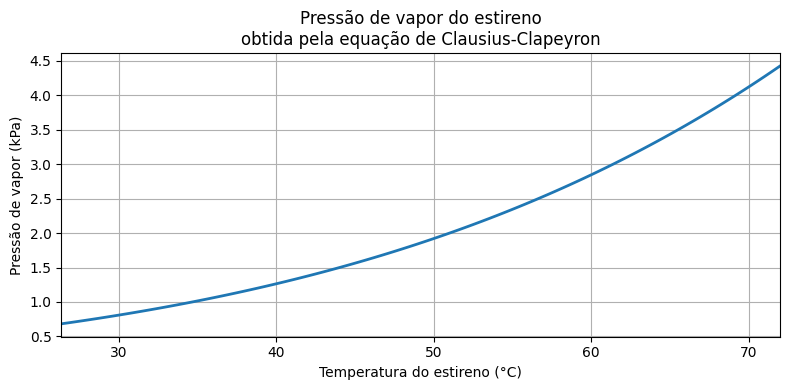

In [47]:
# ============================================================
# 7.1 - Pressão de vapor pelo modelo de Clausius-Clapeyron
# ============================================================

# Temperatura (°C)
temperatura = np.linspace(T_inicial, 72, 100)

# ------------------------------------------------------------
# Dados de referência
# ------------------------------------------------------------

# Pressão de vapor a 25 °C
Pv_ref = 0.64e3          # Pa

# Temperatura de referência
T_ref = 25.0 + 273.15    # K

# Calor molar de vaporização
Hvap = 35.2e3            # J/mol

# Constante universal
R = 8.314                # J/(mol.K)

# ------------------------------------------------------------
# Temperatura absoluta
# ------------------------------------------------------------

T_K = temperatura + 273.15

# ------------------------------------------------------------
# Clausius-Clapeyron
# ------------------------------------------------------------

P_vapor = Pv_ref * np.exp(
    -Hvap/R * (1/T_K - 1/T_ref)
)

# ============================================================
# Resultados
# ============================================================

print("="*60)
print("PRESSÃO DE VAPOR - CLAUSIUS-CLAPEYRON")
print("="*60)

print(f"Temperatura inicial........ {T_inicial:.2f} °C")
print(f"Temperatura final.......... {temperatura[-1]:.2f} °C")

print()

print(f"Pressão de vapor a 25 °C... {Pv_ref/1000:.2f} kPa")
print(f"Pressão de vapor a 72 °C... {P_vapor[-1]/1000:.2f} kPa")

print()

print(f"Aumento da pressão......... {P_vapor[-1]/Pv_ref:.2f} vezes")

print("="*60)

# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(8,4))

plt.plot(
    temperatura,
    P_vapor/1000,
    linewidth=2
)

plt.grid(True)

plt.xlim(T_inicial,72)

plt.xlabel("Temperatura do estireno (°C)")
plt.ylabel("Pressão de vapor (kPa)")

plt.title(
    "Pressão de vapor do estireno\n"
    "obtida pela equação de Clausius-Clapeyron"
)

plt.tight_layout()

plt.show()

# 8 – Energia liberada pela polimerização

Nas seções anteriores foi demonstrado que a radiação solar e a convecção atmosférica produzem apenas um pequeno aumento na temperatura do estireno armazenado no reservatório. Entretanto, as análises térmicas do acidente indicaram que a temperatura média do líquido atingiu aproximadamente **72 °C**, valor muito superior ao previsto apenas pelos mecanismos de transferência de calor considerados.

Surge então uma nova questão:

> **Quanto estireno precisou sofrer polimerização para fornecer a energia necessária para elevar a temperatura do sistema até aproximadamente 72 °C?**

A polimerização do estireno é uma reação química exotérmica, ou seja, libera energia na forma de calor. Admitindo que esse calor permaneça armazenado no sistema, a energia liberada pela reação pode ser estimada por

$$
Q_{pol}=m_{pol}\Delta H_{pol}
$$

em que:

- $Q_{pol}$ é a energia liberada pela reação (J);
- $m_{pol}$ é a massa de estireno que sofreu polimerização (kg);
- $\Delta H_{pol}$ é o calor específico de polimerização (J/kg).

Como a energia necessária para elevar a temperatura do sistema de aproximadamente **26,35 °C** para **72 °C** já foi determinada na Seção 6, pode-se inverter essa equação para estimar diretamente a massa que precisou reagir,

$$
m_{pol}=\frac{Q_{pol}}{\Delta H_{pol}}
$$

Ao final desta seção serão determinados:

1. a energia necessária para explicar o aquecimento observado;
2. a massa de estireno polimerizada;
3. a fração da massa total que reagiu.

Esses resultados serão utilizados posteriormente para discutir como a polimerização pode intensificar a evaporação e contribuir para o aumento da pressão interna do reservatório.

POLIMERIZAÇÃO
Temperatura inicial........ 26.35 °C
Temperatura final.......... 72.00 °C

Variação de temperatura.... 45.65 °C

Energia necessária......... 666.98 GJ

Calor de polimerização..... 635 kJ/kg

Massa polimerizada......... 1050.70 t

Fração polimerizada........ 12.49 %


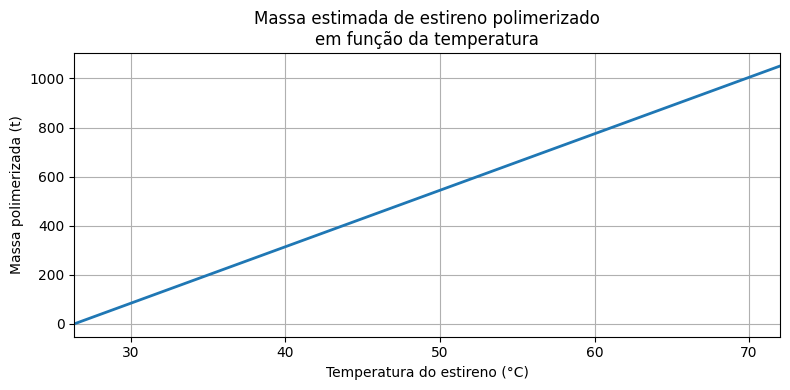

In [48]:
# ============================================================
# 8 - Energia liberada pela polimerização
# ============================================================
#
# Objetivo:
#
# Estimar qual massa de estireno precisou sofrer
# polimerização para elevar a temperatura do sistema
# até aproximadamente 72 °C.
#
# ============================================================

# ------------------------------------------------------------
# Temperaturas
# ------------------------------------------------------------

T_inicial = T_est[0]

T_final = 72.0

deltaT = T_final - T_inicial

# ------------------------------------------------------------
# Energia necessária
# ------------------------------------------------------------

Q_pol = capacidade_termica * deltaT

# ------------------------------------------------------------
# Calor de polimerização
# ------------------------------------------------------------

# Entalpia específica de polimerização do estireno
# Chen, Duh e Shu (2009)

DeltaH_pol = 634.8e3      # J/kg

# ------------------------------------------------------------
# Massa polimerizada
# ------------------------------------------------------------

massa_pol = Q_pol / DeltaH_pol

# ------------------------------------------------------------
# Fração polimerizada
# ------------------------------------------------------------

fracao_pol = massa_pol / massa_estireno



# ============================================================
# Resultados
# ============================================================

print("="*60)
print("POLIMERIZAÇÃO")
print("="*60)

print(f"Temperatura inicial........ {T_inicial:.2f} °C")
print(f"Temperatura final.......... {T_final:.2f} °C")

print()

print(f"Variação de temperatura.... {deltaT:.2f} °C")

print()

print(f"Energia necessária......... {Q_pol/1e9:.2f} GJ")

print()

print(f"Calor de polimerização..... {DeltaH_pol/1000:.0f} kJ/kg")

print()

print(f"Massa polimerizada......... {massa_pol/1000:.2f} t")

print()

print(f"Fração polimerizada........ {100*fracao_pol:.2f} %")

print("="*60)



# ============================================================
# Influência da temperatura na massa polimerizada
# ============================================================

temperatura = np.linspace(T_inicial,72,100)

energia = capacidade_termica * (
    temperatura - T_inicial
)

massa_pol = energia / DeltaH_pol

plt.figure(figsize=(8,4))

plt.plot(
    temperatura,
    massa_pol/1000,
    linewidth=2
)

plt.grid(True)

plt.xlabel("Temperatura do estireno (°C)")

plt.ylabel("Massa polimerizada (t)")

plt.title(
    "Massa estimada de estireno polimerizado\n"
    "em função da temperatura"
)

plt.xlim(T_inicial,72)

plt.tight_layout()

plt.show()


# 9 – Integridade estrutural

Na seção anterior foi estimada a pressão interna desenvolvida no reservatório a partir de dois modelos distintos.

O modelo baseado na Lei dos Gases Ideais forneceu uma condição limite, enquanto a equação de Clausius–Clapeyron produziu valores compatíveis com o equilíbrio líquido-vapor do estireno.

Surge então uma nova questão:

> **A pressão interna estimada é suficiente para comprometer a integridade estrutural do tanque?**

Para responder essa pergunta será utilizado um modelo simplificado baseado na teoria de cascas cilíndricas de parede fina.

Embora reservatórios atmosféricos sejam projetados conforme a norma API 650, as equações clássicas para vasos de pressão permitem estimar a ordem de grandeza das tensões desenvolvidas na parede do tanque e comparar esses valores com o limite de escoamento do aço ASTM A36.

A tensão circunferencial (ou tensão de aro) é dada por

$$
\sigma_\theta
=
\frac{Pr}{t},
$$

em que

- $P$ é a pressão interna (Pa);
- $r$ é o raio interno do tanque (m);
- $t$ é a espessura da parede (m).

A tensão longitudinal pode ser estimada por

$$
\sigma_L
=
\frac{Pr}{2t}.
$$

Finalmente, o fator de segurança é calculado por

$$
FS
=
\frac{\sigma_y}
{\sigma_\theta},
$$

em que $\sigma_y$ representa o limite de escoamento do aço ASTM A36.

Ao final desta seção serão determinados:

1. tensão circunferencial;
2. tensão longitudinal;
3. fator de segurança do reservatório.

Esses resultados permitirão avaliar se a pressão interna calculada nas seções anteriores seria capaz de produzir plastificação da parede do tanque.

INTEGRIDADE ESTRUTURAL
Pressão interna............. 4.43 kPa

Raio do tanque.............. 13.70 m
Espessura mínima........... 6.0 mm

Tensão circunferencial...... 10.105 MPa
Tensão longitudinal......... 5.053 MPa

Limite de escoamento........ 250 MPa
Fator de segurança.......... 24.7


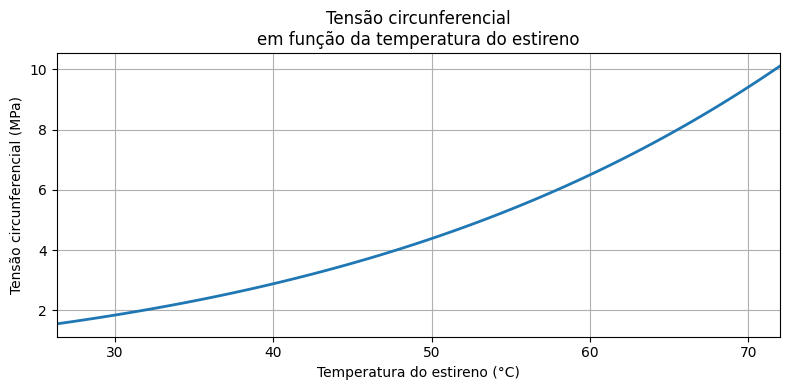

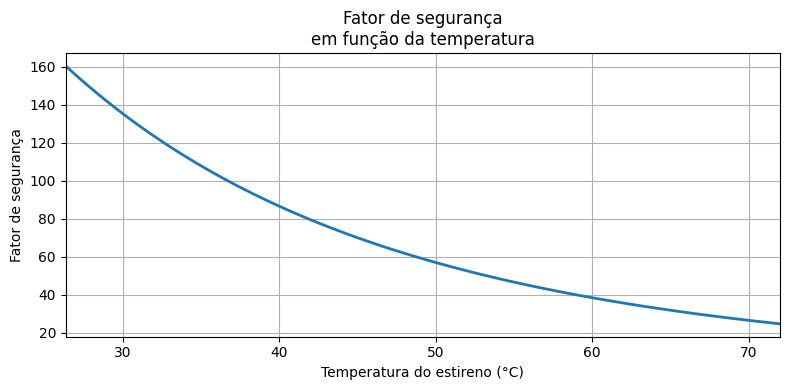

In [49]:
# ============================================================
# 9 - Integridade estrutural
# ============================================================
#
# Modelo:
#
# Casca cilíndrica de parede fina
#
# ============================================================

# ------------------------------------------------------------
# Propriedades do material
# ------------------------------------------------------------

sigma_escoamento = 250e6      # Pa (ASTM A36)

# ------------------------------------------------------------
# Geometria
# ------------------------------------------------------------

r = tanque.raio

# Espessura mínima do casco
# (condição mais crítica)

t = np.min(tanque.espessuras)

# ------------------------------------------------------------
# Pressão interna
# ------------------------------------------------------------

# Utiliza o modelo físico mais realista

P = P_vapor[-1]

# ------------------------------------------------------------
# Tensões
# ------------------------------------------------------------

sigma_theta = P * r / t

sigma_long = P * r / (2*t)

# ------------------------------------------------------------
# Fator de segurança
# ------------------------------------------------------------

FS = sigma_escoamento / sigma_theta

# ============================================================
# Resultados
# ============================================================

print("="*60)
print("INTEGRIDADE ESTRUTURAL")
print("="*60)

print(f"Pressão interna............. {P/1000:.2f} kPa")

print()

print(f"Raio do tanque.............. {r:.2f} m")
print(f"Espessura mínima........... {1000*t:.1f} mm")

print()

print(f"Tensão circunferencial...... {sigma_theta/1e6:.3f} MPa")
print(f"Tensão longitudinal......... {sigma_long/1e6:.3f} MPa")

print()

print(f"Limite de escoamento........ {sigma_escoamento/1e6:.0f} MPa")

print(f"Fator de segurança.......... {FS:.1f}")

print("="*60)




temperatura = np.linspace(T_inicial,72,100)

T_K = temperatura + 273.15

P = Pv_ref*np.exp(
    -Hvap/R*(1/T_K-1/T_ref)
)

sigma = P*r/t

plt.figure(figsize=(8,4))

plt.plot(
    temperatura,
    sigma/1e6,
    linewidth=2
)

plt.grid(True)

plt.xlabel("Temperatura do estireno (°C)")

plt.ylabel("Tensão circunferencial (MPa)")

plt.title(
    "Tensão circunferencial\n"
    "em função da temperatura do estireno"
)

plt.xlim(T_inicial,72)

plt.tight_layout()

plt.show()



FS = sigma_escoamento/sigma

plt.figure(figsize=(8,4))

plt.plot(
    temperatura,
    FS,
    linewidth=2
)

plt.grid(True)

plt.xlabel("Temperatura do estireno (°C)")

plt.ylabel("Fator de segurança")

plt.title(
    "Fator de segurança\n"
    "em função da temperatura"
)

plt.xlim(T_inicial,72)

plt.tight_layout()

plt.show()

# 10 – Dispersão atmosférica

Nas seções anteriores foram estudados os fenômenos que ocorrem no interior do reservatório: transferência de calor, evaporação, pressão interna, polimerização e integridade estrutural.

Surge então uma nova pergunta:

> **Depois que o estireno é liberado para a atmosfera, como ele se espalha pelo ambiente?**

Essa questão é extremamente importante em acidentes industriais, pois a concentração do contaminante no ar determina os riscos à saúde da população e aos trabalhadores próximos ao local.

Nesta seção será utilizado um modelo simplificado para representar a dispersão atmosférica do estireno após um vazamento.

Antes de realizar qualquer cálculo, é importante observar que a nuvem de contaminante sofre a ação de dois processos físicos principais:

- **advecção**, causada pelo vento, que transporta a nuvem na direção do escoamento atmosférico;
- **difusão turbulenta**, responsável pelo espalhamento lateral e vertical da pluma.

Esses dois mecanismos explicam por que um vazamento inicialmente concentrado tende a ocupar uma região cada vez maior à medida que se afasta da fonte emissora.

O modelo mais utilizado para representar esse processo é o **modelo da pluma gaussiana**, cuja concentração é dada por

$$
C(x,y,z)=
\frac{Q}
{2\pi u\sigma_y\sigma_z}
\exp\left(
-\frac{y^2}{2\sigma_y^2}
\right)
\left[
\exp\left(
-\frac{(z-H)^2}{2\sigma_z^2}
\right)
+
\exp\left(
-\frac{(z+H)^2}{2\sigma_z^2}
\right)
\right],
$$

em que:

- $C$ é a concentração do contaminante (g/m³);
- $Q$ é a taxa de emissão da fonte (g/s);
- $u$ é a velocidade média do vento (m/s);
- $\sigma_y$ é o coeficiente de dispersão lateral (m);
- $\sigma_z$ é o coeficiente de dispersão vertical (m);
- $H$ é a altura da fonte emissora (m).

Nesta primeira aplicação será analisada apenas a **linha central da pluma**, isto é,

$$
y=0
\qquad\text{e}\qquad
z=0.
$$

Nessas condições, a equação anterior simplifica-se para

$$
C(x)=
\frac{Q}
{2\pi u\sigma_y\sigma_z}
\exp\left(
-\frac{H^2}
{2\sigma_z^2}
\right),
$$

permitindo estudar como a concentração varia apenas com a distância da fonte.

Ao final desta seção serão determinados:

1. a concentração de estireno ao longo da direção do vento;
2. a influência da velocidade do vento na dispersão da pluma;
3. a redução da concentração com o aumento da distância da fonte.

Embora simplificado, esse modelo é amplamente utilizado em estudos ambientais, segurança de processos e análises preliminares de acidentes industriais, constituindo uma importante ferramenta para compreender os mecanismos básicos de dispersão atmosférica.

*Reflexão*

Antes de apresentar o modelo matemático, vale refletir sobre a seguinte questão:

> **Antes de analisar a equação, tente prever qualitativamente como cada parâmetro influencia a concentração do contaminante.**

Intuitivamente, espera-se que:

- uma **maior taxa de emissão ($Q$)** aumente a concentração do contaminante;
- uma **maior velocidade do vento ($u$)** favoreça a diluição da pluma, reduzindo sua concentração;
- um **maior espalhamento lateral ($\sigma_y$) e vertical ($\sigma_z$)** distribua o contaminante em um volume maior de ar, diminuindo a concentração na região central da pluma.

Para tornar esta atividade integrada às seções anteriores, alguns parâmetros do modelo serão obtidos a partir dos resultados já calculados ao longo do notebook.

**Taxa de emissão ($Q$):** será estimada admitindo-se, para fins didáticos, que a massa máxima evaporada obtida na Seção 6 seja liberada uniformemente durante um intervalo de tempo $\Delta t$. Assim,

$$
Q=\frac{m_{ev}}{\Delta t},
$$

em que $m_{ev}$ é a massa evaporada e $\Delta t$ representa a duração do vazamento.

**Velocidade do vento ($u$):** será adotada a velocidade média obtida a partir dos dados meteorológicos da plataforma **NASA POWER**, utilizada nas seções anteriores.

**Altura da fonte ($H$):** será considerada a altura do reservatório estimada por meio de imagens do Google Earth/Google Maps.

Obs: A massa evaporada utilizada na pluma gaussiana é um limite teórico energético, não uma estimativa da massa efetivamente liberada durante o acidente.

In [50]:
# ============================================================
# 10 - Dispersão Atmosférica
# ============================================================
#
# Modelo simplificado
#
# Pluma Gaussiana
#
# Objetivo:
#
# Estimar a concentração de estireno ao longo da direção
# do vento após um vazamento.
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Taxa de emissão
# ------------------------------------------------------------
# A taxa média de emissão é calculada utilizando a massa
# evaporada estimada na Seção 6.
#
# Hipótese didática:
# toda a massa evaporada é liberada uniformemente durante
# um intervalo de tempo Δt.
# ------------------------------------------------------------

tempo_vazamento = 24      # h

tempo_seg = tempo_vazamento * 3600

Q = massa_evaporavel_max / tempo_seg      # kg/s

# ------------------------------------------------------------
# Velocidade média do vento
# ------------------------------------------------------------
# Média obtida a partir dos dados meteorológicos da
# plataforma NASA POWER.
#
# Caso a variável já tenha sido criada anteriormente,
# basta utilizá-la diretamente.
# ------------------------------------------------------------

# Velocidade média do vento obtida da plataforma NASA POWER

u = np.mean(vento)     # m/s

# ------------------------------------------------------------
# Altura da fonte
# ------------------------------------------------------------
# Utiliza a altura do reservatório definida na seção de
# geometria do tanque.
# ------------------------------------------------------------

H = tanque.altura      # m

# ------------------------------------------------------------
# Distância da fonte
# ------------------------------------------------------------

x = np.linspace(1,1000,400)

# ------------------------------------------------------------
# Classe de estabilidade atmosférica
# ------------------------------------------------------------
# Classe D de Pasquill-Gifford
# (condição atmosférica neutra)
# ------------------------------------------------------------

sigma_y = (
    0.08*x*
    (1+0.0001*x)**(-0.5)
)

sigma_z = (
    0.06*x*
    (1+0.0015*x)**(-0.5)
)

# ------------------------------------------------------------
# Concentração na linha central da pluma
# ------------------------------------------------------------

C = (
    Q /
    (
        2*np.pi*u*sigma_y*sigma_z
    )
) * np.exp(
    -(H**2)/(2*sigma_z**2)
)

# ============================================================
# Resultados
# ============================================================

print("="*60)
print("DISPERSÃO ATMOSFÉRICA")
print("="*60)

print(f"Massa evaporada............. {massa_evaporavel_max/1000:.1f} t")

print(f"Tempo do vazamento.......... {tempo_vazamento:.1f} h")

print()

print(f"Taxa média de emissão....... {Q:.2f} kg/s")

print()

print(f"Velocidade média do vento... {u:.2f} m/s")

print(f"Altura da fonte............. {H:.1f} m")

print("Classe atmosférica.......... D")

print()

print(f"Concentração máxima......... {1e6*C.max():.1f} mg/m³")

indice500 = np.argmin(np.abs(x-500))

print(f"Concentração a 500 m........ {1e6*C[indice500]:.1f} mg/m³")

print(f"Concentração a 1000 m....... {1e6*C[-1]:.1f} mg/m³")

print("="*60)

DISPERSÃO ATMOSFÉRICA
Massa evaporada............. 1967.5 t
Tempo do vazamento.......... 24.0 h

Taxa média de emissão....... 22.77 kg/s

Velocidade média do vento... 1.42 m/s
Altura da fonte............. 17.5 m
Classe atmosférica.......... D

Concentração máxima......... 3991.5 mg/m³
Concentração a 500 m........ 2141.1 mg/m³
Concentração a 1000 m....... 791.4 mg/m³


## 10.1 – Visualização da concentração ao longo da direção do vento

Após definir os parâmetros da fonte emissora e das condições meteorológicas, pode-se calcular como a concentração de estireno varia ao longo da direção do vento utilizando o modelo da pluma gaussiana.

Nesta análise é considerada a **linha central da pluma** (\(y=0\) e \(z=0\)), região onde são previstas as maiores concentrações do contaminante. À medida que a distância da fonte aumenta, a ação do vento e da difusão turbulenta promove o espalhamento da pluma, reduzindo progressivamente a concentração de estireno na atmosfera.

O gráfico a seguir apresenta a concentração de estireno, expressa em **mg/m³**, em função da distância da fonte emissora. A partir dessa análise, é possível identificar as regiões mais afetadas pelo vazamento e compreender a influência da dispersão atmosférica na redução da concentração do contaminante.

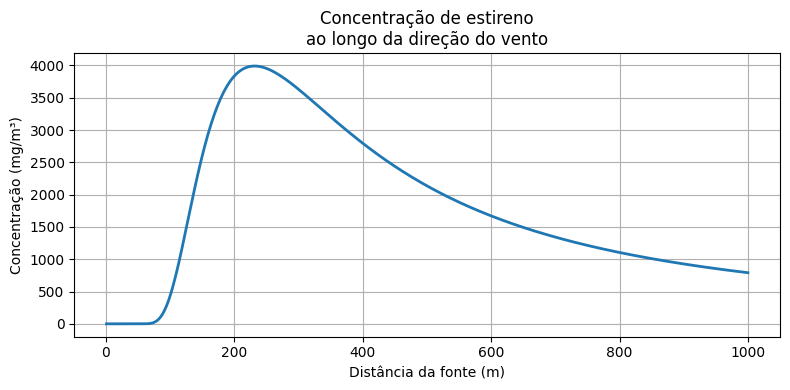

In [51]:
# ===============================================================
# 10.1 - Visualização da concentração ao longo da direção do vento
# ===============================================================

plt.figure(figsize=(8,4))

plt.plot(
    x,
    C*1e6,          # kg/m³ -> mg/m³
    linewidth=2
)

plt.grid(True)

plt.xlabel("Distância da fonte (m)")

plt.ylabel("Concentração (mg/m³)")

plt.title(
    "Concentração de estireno\n"
    "ao longo da direção do vento"
)

plt.tight_layout()

plt.show()

## 10.2 – Influência da velocidade do vento

A velocidade do vento é um dos principais fatores que controlam a dispersão de contaminantes na atmosfera. Em geral, ventos mais intensos transportam a pluma com maior rapidez e promovem uma diluição mais eficiente do poluente, reduzindo sua concentração ao longo da direção do escoamento.

Para investigar esse efeito, serão simulados diferentes valores de velocidade do vento, mantendo constantes os demais parâmetros do modelo. Dessa forma, é possível avaliar como as condições meteorológicas influenciam a concentração de estireno prevista pelo modelo da pluma gaussiana.

O gráfico a seguir apresenta a variação da concentração de estireno, expressa em **mg/m³**, em função da distância da fonte emissora para diferentes velocidades médias do vento.

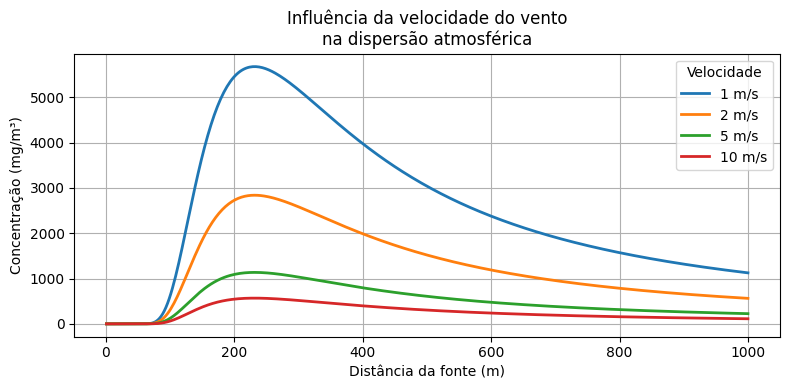

In [52]:
# ============================================================
# 10.2 - Influência da velocidade do vento
# ============================================================

plt.figure(figsize=(8,4))

for u in [1, 2, 5, 10]:

    C = (
        Q
        /
        (
            2*np.pi*u*sigma_y*sigma_z
        )
        *
        np.exp(
            -(H**2)/(2*sigma_z**2)
        )
    )

    plt.plot(
        x,
        C*1e6,              # kg/m³ → mg/m³
        linewidth=2,
        label=f"{u} m/s"
    )

plt.grid(True)

plt.xlabel("Distância da fonte (m)")

plt.ylabel("Concentração (mg/m³)")

plt.title(
    "Influência da velocidade do vento\n"
    "na dispersão atmosférica"
)

plt.legend(title="Velocidade")

plt.tight_layout()

plt.show()

## 11 – Síntese e considerações finais

<div align="center">
<h3>O que os modelos físicos e computacionais permitem concluir sobre o acidente com estireno em Manaus?</h3>
</div>

A análise desenvolvida neste notebook permitiu investigar os mecanismos de transferência de calor envolvidos no armazenamento de estireno, relacionando as propriedades físico-químicas do produto, as características geométricas do reservatório e as condições ambientais. Por meio de um modelo de parâmetros concentrados, foi possível estimar a evolução temporal da temperatura do líquido e avaliar as contribuições da radiação solar e da convecção para o balanço global de energia.

Os resultados constituem uma primeira aproximação da dinâmica térmica do sistema e devem ser interpretados considerando as hipóteses e simplificações adotadas. A comparação entre as temperaturas estimadas e as observadas durante o acidente permite discutir a capacidade explicativa dos mecanismos ambientais considerados e identificar a necessidade de investigar outros processos físicos.

Entre as possibilidades de aprimoramento do modelo, destacam-se a inclusão da transferência de calor por radiação térmica, a representação mais detalhada da condução através das paredes do tanque e a investigação do calor liberado por uma possível reação de polimerização do estireno. Esses mecanismos podem ser incorporados progressivamente, permitindo construir modelos mais abrangentes e avaliar sua influência sobre a evolução térmica do sistema.

Do ponto de vista didático, a atividade demonstra como conceitos de termodinâmica, transferência de calor e propriedades da matéria podem ser articulados em uma investigação baseada em dados reais e simulações computacionais. A possibilidade de modificar parâmetros, testar hipóteses e comparar cenários favorece o desenvolvimento do raciocínio científico e a compreensão das potencialidades e limitações da modelagem física.
